# Notebook 00C_B — Análise Completa: Stanford CheXpert

**JPEG resolução variável | Drive | ~224k imagens**

Análise isolada do CheXpert. Rodar em paralelo com `00C_A_NIH_Analysis`.

## Célula 1 — Dependências

In [ ]:
!pip install -q pandas numpy matplotlib seaborn Pillow tqdm
print('Dependências instaladas.')

Dependências instaladas.


## Célula 2 — Drive, caminhos e pasta de saída

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

BASE_DRIVE  = '/content/drive/MyDrive'
DATASET_DIR = f'{BASE_DRIVE}/datasets_pi_2026'

# ── CheXpert: JPEG resolução variável — lido do Drive ─────
CHEX_DIR     = f'{DATASET_DIR}/CheXpert_extracted'
CHEX_CSV_DIR = f'{CHEX_DIR}/meta'

RESULTS_DIR  = f'{BASE_DRIVE}/Results'
ANALYSIS_DIR = f'{RESULTS_DIR}/analise_CheXpert'
PLOTS_CHEX   = f'{ANALYSIS_DIR}/plots'
TABLES_DIR   = f'{ANALYSIS_DIR}/tabelas'
REPORT_PATH  = f'{ANALYSIS_DIR}/relatorio_CheXpert.txt'

for d in [ANALYSIS_DIR, PLOTS_CHEX, TABLES_DIR]:
    os.makedirs(d, exist_ok=True)

for f, lbl in [
    (f'{CHEX_CSV_DIR}/train.csv', 'CheXpert train.csv'),
    (f'{CHEX_CSV_DIR}/valid.csv', 'CheXpert valid.csv'),
]:
    print(f"{'✅' if os.path.exists(f) else '❌'} {lbl}")

Mounted at /content/drive
✅ CheXpert train.csv
✅ CheXpert valid.csv


## Célula 3 — Imports, constantes e utilitários

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import Counter
from itertools import combinations
import glob, warnings, time, os, json
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 12, 'axes.labelsize': 11,
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False
})

C_NIH  = '#185FA5'
C_CHEX = '#0F6E56'
C_WARN = '#D85A30'
C_AMB  = '#854F0B'
C_GRAY = '#888780'

NIH_LABELS = [
    'Atelectasis','Cardiomegaly','Effusion','Infiltration',
    'Mass','Nodule','Pneumonia','Pneumothorax',
    'Consolidation','Edema','Emphysema','Fibrosis',
    'Pleural_Thickening','Hernia'
]
CHEX_LABELS = [
    'Atelectasis','Cardiomegaly','Consolidation','Edema',
    'Enlarged Cardiomediastinum','Fracture','Lung Lesion',
    'Lung Opacity','No Finding','Pleural Effusion',
    'Pleural Other','Pneumonia','Pneumothorax','Support Devices'
]
CHEX_LABELS_NO_NF = [l for l in CHEX_LABELS if l != 'No Finding']

NIH_TO_CHEX = {
    'Atelectasis': 'Atelectasis', 'Cardiomegaly': 'Cardiomegaly',
    'Effusion': 'Pleural Effusion', 'Pneumonia': 'Pneumonia',
    'Pneumothorax': 'Pneumothorax', 'Consolidation': 'Consolidation',
    'Edema': 'Edema',
}

REPORT_LINES = []

def log(msg=''):
    print(msg)
    REPORT_LINES.append(msg)

def save_fig(fig, path, tight=True):
    if tight:
        plt.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Salvo: {path.replace(BASE_DRIVE, "MyDrive")}')

def section(title):
    log()
    log('=' * 65)
    log(title)
    log('=' * 65)

print('Imports e utilitários prontos.')

Imports e utilitários prontos.


## Célula 4 — Carregar dataset CheXpert

In [ ]:
df_chex_train = pd.read_csv(f'{CHEX_CSV_DIR}/train.csv')
df_chex_valid = pd.read_csv(f'{CHEX_CSV_DIR}/valid.csv')
df_chex_valid['split'] = 'valid'
df_chex_train['split'] = 'train'
df_chex = pd.concat([df_chex_train, df_chex_valid], ignore_index=True)

# Construir batch_index para resolver paths no Drive
batch_index = {}
for batch in ['batch2_train1', 'batch3_train2', 'batch4_train3']:
    bp = f'{CHEX_DIR}/{batch}'
    if os.path.exists(bp):
        for pt in os.listdir(bp):
            if pt.startswith('patient'):
                batch_index[pt] = batch

def resolve_chex_path(csv_path):
    parts = str(csv_path).split('/')
    if len(parts) < 3: return None
    patient = parts[2]; rest = '/'.join(parts[3:])
    if patient in batch_index:
        return f'{CHEX_DIR}/{batch_index[patient]}/{patient}/{rest}'
    vp = f'{CHEX_DIR}/batch1_validate_csv/valid/{patient}/{rest}'
    return vp if os.path.exists(vp) else None

df_chex['abs_path'] = df_chex['Path'].apply(resolve_chex_path)
df_chex_train['abs_path'] = df_chex_train['Path'].apply(resolve_chex_path)
df_chex_valid['abs_path'] = df_chex_valid['Path'].apply(resolve_chex_path)

if 'Frontal/Lateral' in df_chex.columns:
    df_chex['view_type'] = df_chex['Frontal/Lateral']
if 'Frontal/Lateral' in df_chex_train.columns:
    df_chex_train['view_type'] = df_chex_train['Frontal/Lateral']

print(f'CheXpert carregado: {len(df_chex):,} imagens')
print(f'  Formato: JPEG resolução variável (~2000-3000 px) | Fonte: Drive')
print(f'  Pacientes indexados: {len(batch_index):,}')
print(f'  Train: {len(df_chex_train):,} | Valid: {len(df_chex_valid):,}')

CheXpert carregado: 223,648 imagens
  Formato: JPEG resolução variável (~2000-3000 px) | Fonte: Drive
  Pacientes indexados: 64,540
  Train: 223,414 | Valid: 234


---
# SEÇÃO 1 — Distribuição de Tamanhos de Imagem

### SEÇÃO 1A — Mapear estrutura de pastas CheXpert

In [ ]:
section('SEÇÃO 1A — Mapeando estrutura de pastas do CheXpert')

import os, json
from PIL import Image

CKPT_PATH = f'{ANALYSIS_DIR}/ckpt_sec01_sizes.json'

# ── Descobrir todas as pastas de paciente por batch ───────────────────────────
batch_folders = {}
for batch in ['batch2_train1', 'batch3_train2', 'batch4_train3']:
    bp = f'{CHEX_DIR}/{batch}'
    if not os.path.exists(bp):
        log(f'  ⚠️  Batch não encontrado: {batch}')
        continue
    patients = sorted([p for p in os.listdir(bp) if p.startswith('patient')])
    batch_folders[batch] = patients
    log(f'  {batch}: {len(patients):,} pacientes')

total_patients = sum(len(v) for v in batch_folders.values())
log(f'\n  Total de pacientes: {total_patients:,}')

# ── Criar lista de trabalho: (batch, patient) ─────────────────────────────────
work_list = []
for batch, patients in batch_folders.items():
    for patient in patients:
        work_list.append((batch, patient))

log(f'  Lista de trabalho: {len(work_list):,} entradas')
log(f'\n  Checkpoint em: {CKPT_PATH.replace(BASE_DRIVE, "MyDrive")}')
log('  Execute a SEÇÃO 1B para iniciar/retomar a medição pasta a pasta.')


SEÇÃO 1A — Mapeando estrutura de pastas do CheXpert
  batch2_train1: 21,513 pacientes
  batch3_train2: 21,504 pacientes
  batch4_train3: 21,523 pacientes

  Total de pacientes: 64,540
  Lista de trabalho: 64,540 entradas

  Checkpoint em: MyDrive/Results/analise_CheXpert/ckpt_sec01_sizes.json
  Execute a SEÇÃO 1B para iniciar/retomar a medição pasta a pasta.


### SEÇÃO 1B — Medir tamanhos pasta a pasta (retomável)

In [ ]:
# ── Carregar checkpoint existente ────────────────────────────────────────────
def load_ckpt():
    if os.path.exists(CKPT_PATH):
        with open(CKPT_PATH, 'r') as f:
            return json.load(f)
    return {'done_patients': [], 'sizes_frontal': [], 'sizes_lateral': [],
            'failed': [], 'n_processed': 0}

def save_ckpt(data):
    with open(CKPT_PATH, 'w') as f:
        json.dump(data, f)

ckpt = load_ckpt()
done_set = set(ckpt['done_patients'])

pending = [(b, p) for b, p in work_list if f'{b}/{p}' not in done_set]

log(f'Situação atual:')
log(f'  Pacientes concluídos : {len(done_set):,}')
log(f'  Pendentes            : {len(pending):,}')
log(f'  Frontais medidas     : {len(ckpt["sizes_frontal"]):,}')
log(f'  Laterais medidas     : {len(ckpt["sizes_lateral"]):,}')
log(f'  Falhas               : {len(ckpt["failed"]):,}')

if not pending:
    log('\n  ✅ Medição completa! Execute a SEÇÃO 1C para gerar os plots.')
else:
    log(f'\n  Iniciando medição... (salva após cada paciente)')
    log(f'  Re-execute esta célula se o notebook cair — retoma do ponto salvo.\n')

# ── Processar pasta por pasta ─────────────────────────────────────────────────
SAVE_EVERY = 50   # salva checkpoint a cada 50 pacientes

for i, (batch, patient) in enumerate(pending):
    patient_key = f'{batch}/{patient}'
    patient_dir = f'{CHEX_DIR}/{batch}/{patient}'

    try:
        for study in os.listdir(patient_dir):
            study_dir = f'{patient_dir}/{study}'
            if not os.path.isdir(study_dir):
                continue
            for fname in os.listdir(study_dir):
                if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    continue
                fpath = f'{study_dir}/{fname}'
                fname_lower = fname.lower()
                try:
                    with Image.open(fpath) as img:
                        size = list(img.size)
                    # Classify by filename
                    if 'frontal' in fname_lower or 'front' in fname_lower:
                        ckpt['sizes_frontal'].append(size)
                    elif 'lateral' in fname_lower or 'lat' in fname_lower:
                        ckpt['sizes_lateral'].append(size)
                    else:
                        # Fallback: usa view_type do CSV se disponível
                        ckpt['sizes_frontal'].append(size)
                except Exception as e:
                    ckpt['failed'].append({'path': fpath, 'error': str(e)})
    except Exception as e:
        ckpt['failed'].append({'path': patient_dir, 'error': str(e)})

    ckpt['done_patients'].append(patient_key)
    done_set.add(patient_key)
    ckpt['n_processed'] += 1

    # Salva checkpoint a cada SAVE_EVERY pacientes
    if (i + 1) % SAVE_EVERY == 0:
        save_ckpt(ckpt)
        total_done = len(done_set)
        pct = total_done / len(work_list) * 100
        print(f'  [{total_done:,}/{len(work_list):,} — {pct:.1f}%] '
              f'F:{len(ckpt["sizes_frontal"]):,} L:{len(ckpt["sizes_lateral"]):,} '
              f'Erros:{len(ckpt["failed"])}', flush=True)

# Checkpoint final
save_ckpt(ckpt)
log(f'\nCélula concluída.')
log(f'  Pacientes processados nesta execução: {len(pending):,}')
log(f'  Total concluídos: {len(ckpt["done_patients"]):,}/{len(work_list):,}')
log(f'  Frontais: {len(ckpt["sizes_frontal"]):,} | Laterais: {len(ckpt["sizes_lateral"]):,}')
log(f'  Falhas  : {len(ckpt["failed"]):,}')

if len(ckpt['done_patients']) < len(work_list):
    restantes = len(work_list) - len(ckpt['done_patients'])
    log(f'\n  ⚠️  Ainda faltam {restantes:,} pacientes. Re-execute esta célula.')
else:
    log('\n  ✅ Todos os pacientes processados! Execute a SEÇÃO 1C.')

Situação atual:
  Pacientes concluídos : 64,540
  Pendentes            : 0
  Frontais medidas     : 191,028
  Laterais medidas     : 32,388
  Falhas               : 0

  ✅ Medição completa! Execute a SEÇÃO 1C para gerar os plots.

Célula concluída.
  Pacientes processados nesta execução: 0
  Total concluídos: 64,540/64,540
  Frontais: 191,028 | Laterais: 32,388
  Falhas  : 0

  ✅ Todos os pacientes processados! Execute a SEÇÃO 1C.


### SEÇÃO 1B-alt — Reclassificar Frontal/Lateral via CSV (opcional, mais preciso)

In [ ]:
# ── SEÇÃO 1B-alt | Célula 1 — Relatórios independentes ───────────────────────

ckpt = load_ckpt()
total_done = len(ckpt['done_patients'])
total_work = len(work_list)
completo   = total_done >= total_work

log('=' * 60)
log('RELATÓRIO 1 — SEÇÃO 1B (classificação por nome de arquivo)')
log('=' * 60)
frontal_ckpt = len(ckpt['sizes_frontal'])
lateral_ckpt = len(ckpt['sizes_lateral'])
total_ckpt   = frontal_ckpt + lateral_ckpt
ratio_ckpt   = frontal_ckpt / lateral_ckpt if lateral_ckpt > 0 else 0
log(f'  Status           : {total_done:,}/{total_work:,} pacientes '
    f'({"COMPLETO" if completo else "PARCIAL"})')
log(f'  Frontais medidas : {frontal_ckpt:,}')
log(f'  Laterais medidas : {lateral_ckpt:,}')
log(f'  Total            : {total_ckpt:,}')
log(f'  Ratio F/L        : {ratio_ckpt:.3f}')
log(f'  Falhas           : {len(ckpt["failed"]):,}')

log('')
log('=' * 60)
log('RELATÓRIO 2 — CSV Stanford (fonte de verdade)')
log('=' * 60)
frontal_csv = int((df_chex_train['view_type'] == 'Frontal').sum())
lateral_csv = int((df_chex_train['view_type'] == 'Lateral').sum())
total_csv   = frontal_csv + lateral_csv
ratio_csv   = frontal_csv / lateral_csv if lateral_csv > 0 else 0
log(f'  Frontais no CSV  : {frontal_csv:,}')
log(f'  Laterais no CSV  : {lateral_csv:,}')
log(f'  Total no CSV     : {total_csv:,}')
log(f'  Ratio F/L        : {ratio_csv:.3f}')

if 'split' in df_chex_train.columns:
    log(f'\n  Por split:')
    for split in df_chex_train['split'].unique():
        sub = df_chex_train[df_chex_train['split'] == split]
        f   = int((sub['view_type'] == 'Frontal').sum())
        l   = int((sub['view_type'] == 'Lateral').sum())
        r   = f'{f/l:.2f}' if l > 0 else 'N/A'
        log(f'  {split:<8}: Frontal={f:,} | Lateral={l:,} | Ratio={r}')

RELATÓRIO 1 — SEÇÃO 1B (classificação por nome de arquivo)
  Status           : 64,540/64,540 pacientes (COMPLETO)
  Frontais medidas : 191,028
  Laterais medidas : 32,388
  Total            : 223,416
  Ratio F/L        : 5.898
  Falhas           : 0

RELATÓRIO 2 — CSV Stanford (fonte de verdade)
  Frontais no CSV  : 191,027
  Laterais no CSV  : 32,387
  Total no CSV     : 223,414
  Ratio F/L        : 5.898

  Por split:
  train   : Frontal=191,027 | Lateral=32,387 | Ratio=5.90


In [ ]:
# ── SEÇÃO 1B-alt | Célula 2 — Comparativo ────────────────────────────────────
# Execute após a Célula 1 desta seção.

escala      = total_done / total_work if total_work > 0 else 1.0
frontal_esp = int(frontal_csv * escala)
lateral_esp = int(lateral_csv * escala)
total_esp   = frontal_esp + lateral_esp

delta_f     = frontal_ckpt - frontal_esp
delta_l     = lateral_ckpt - lateral_esp
delta_total = total_ckpt   - total_esp
delta_ratio = abs(ratio_ckpt - ratio_csv)

log('=' * 60)
log('COMPARATIVO — Checkpoint (1B) vs CSV Stanford')
log('=' * 60)
log(f'  Escala aplicada  : {escala:.4f} ({total_done:,}/{total_work:,} pacientes)')
log(f'\n  {"Métrica":<20} {"1B (ckpt)":>12} {"CSV (esp.)":>12} {"Delta":>12} {"Delta %":>10}')
log(f'  {"-"*68}')
log(f'  {"Frontais":<20} {frontal_ckpt:>12,} {frontal_esp:>12,} {delta_f:>+12,} {delta_f/frontal_esp*100:>+9.2f}%')
log(f'  {"Laterais":<20} {lateral_ckpt:>12,} {lateral_esp:>12,} {delta_l:>+12,} {delta_l/lateral_esp*100:>+9.2f}%')
log(f'  {"Total":<20} {total_ckpt:>12,} {total_esp:>12,} {delta_total:>+12,} {delta_total/total_esp*100:>+9.2f}%')
log(f'  {"Ratio F/L":<20} {ratio_ckpt:>12.3f} {ratio_csv:>12.3f} {delta_ratio:>+12.4f}')

log(f'\n  Diagnóstico:')
if delta_ratio < 0.05 and abs(delta_f / frontal_esp) < 0.02:
    log('  ✅ Classificação consistente — 1B e CSV estão alinhados.')
    log('     Não é necessário executar reclassificação.')
elif delta_ratio < 0.10:
    log('  ⚠️  Pequena divergência — efeito provável do fallback da 1B.')
    log('     Aceitável para análise exploratória.')
else:
    log('  ❌ Divergência significativa.')
    log('     Recomenda-se reclassificação via CSV após 1B completar.')

COMPARATIVO — Checkpoint (1B) vs CSV Stanford
  Escala aplicada  : 1.0000 (64,540/64,540 pacientes)

  Métrica                 1B (ckpt)   CSV (esp.)        Delta    Delta %
  --------------------------------------------------------------------
  Frontais                  191,028      191,027           +1     +0.00%
  Laterais                   32,388       32,387           +1     +0.00%
  Total                     223,416      223,414           +2     +0.00%
  Ratio F/L                   5.898        5.898      +0.0002

  Diagnóstico:
  ✅ Classificação consistente — 1B e CSV estão alinhados.
     Não é necessário executar reclassificação.


### SEÇÃO 1C — Relatório e plots (execute após 1B completo)

Status: 64,540/64,540 pacientes processados (COMPLETO)
Frontais: 191,028 | Laterais: 32,388
Falhas  : 0

CheXpert Frontal — Tamanhos (191,028 imagens medidas):
  Largura        : min=833 | max=4248 | mediana=2828
  Altura         : min=695 | max=4240 | mediana=2320
  Aspect ratio   : min=0.344 | max=1.349 | médio=0.842
  Portrait (h>w) : 4,349 (2.3%)
  Square  (h=w)  : 10,344
  Tamanhos únicos: 7189

CheXpert Lateral — Tamanhos (32,388 imagens medidas):
  Largura        : min=1006 | max=4240 | mediana=1950
  Altura         : min=907 | max=4248 | mediana=2021
  Aspect ratio   : min=0.675 | max=2.009 | médio=1.112
  Portrait (h>w) : 22,581 (69.7%)
  Square  (h=w)  : 7,191
  Tamanhos únicos: 4177


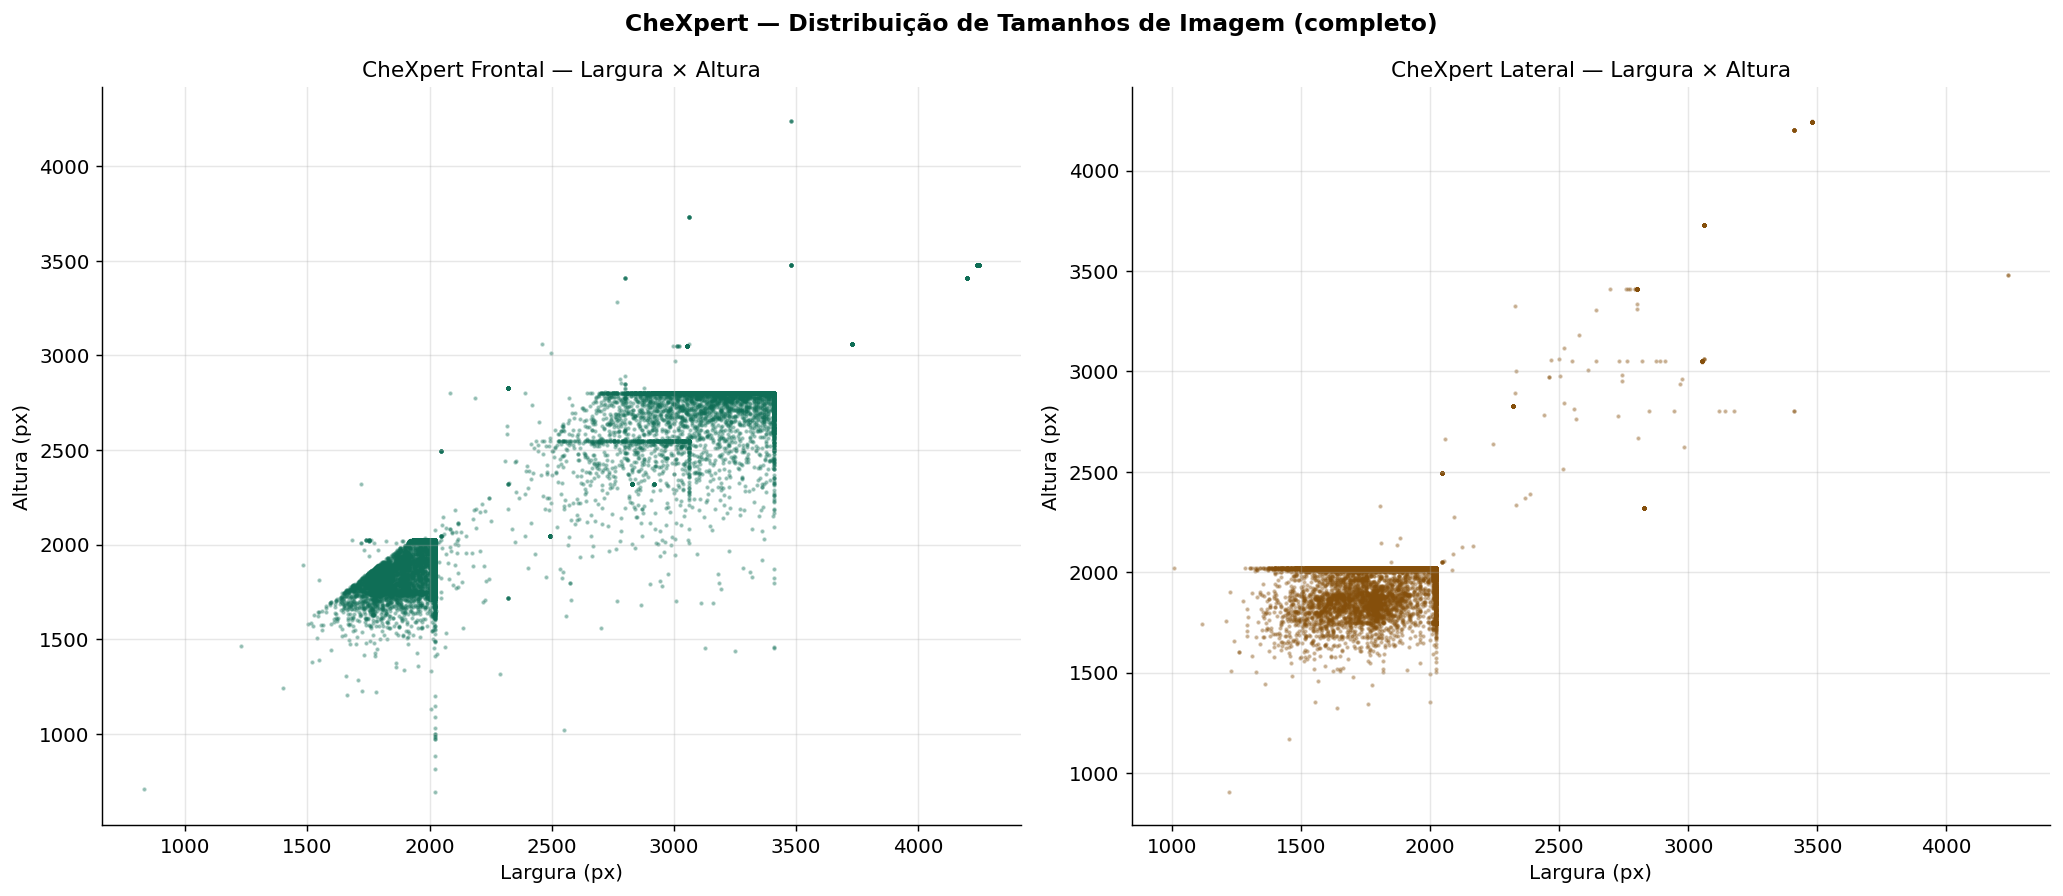

  Salvo: MyDrive/Results/analise_CheXpert/plots/sec01_image_sizes.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

ckpt = load_ckpt()
chex_sizes_frontal = ckpt['sizes_frontal']
chex_sizes_lateral = ckpt['sizes_lateral']

total_done = len(ckpt['done_patients'])
total_work = len(work_list)
completo   = total_done >= total_work

log(f'Status: {total_done:,}/{total_work:,} pacientes processados '
    f'({"COMPLETO" if completo else "PARCIAL — rode 1B novamente"})')
log(f'Frontais: {len(chex_sizes_frontal):,} | Laterais: {len(chex_sizes_lateral):,}')
log(f'Falhas  : {len(ckpt["failed"]):,}')

for lbl, sizes in [('Frontal', chex_sizes_frontal), ('Lateral', chex_sizes_lateral)]:
    if not sizes: continue
    ws = [s[0] for s in sizes]; hs = [s[1] for s in sizes]
    ratios = [h/w for w, h in zip(ws, hs)]
    log(f'\nCheXpert {lbl} — Tamanhos ({len(sizes):,} imagens medidas):')
    log(f'  Largura        : min={min(ws)} | max={max(ws)} | mediana={int(np.median(ws))}')
    log(f'  Altura         : min={min(hs)} | max={max(hs)} | mediana={int(np.median(hs))}')
    log(f'  Aspect ratio   : min={min(ratios):.3f} | max={max(ratios):.3f} | médio={np.mean(ratios):.3f}')
    log(f'  Portrait (h>w) : {sum(1 for r in ratios if r > 1):,} ({sum(1 for r in ratios if r > 1)/len(ratios)*100:.1f}%)')
    log(f'  Square  (h=w)  : {sum(1 for r in ratios if r == 1):,}')
    log(f'  Tamanhos únicos: {len(set(tuple(s) for s in sizes))}')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
status_str = 'completo' if completo else f'parcial — {total_done:,}/{total_work:,} pacientes'
fig.suptitle(f'CheXpert — Distribuição de Tamanhos de Imagem ({status_str})',
             fontsize=13, fontweight='bold')

for ax, sizes, label, color in [
    (axes[0], chex_sizes_frontal, 'Frontal', C_CHEX),
    (axes[1], chex_sizes_lateral, 'Lateral', C_AMB),
]:
    if not sizes: ax.set_visible(False); continue
    ws = [s[0] for s in sizes]; hs = [s[1] for s in sizes]
    ax.scatter(ws, hs, alpha=0.3, s=2, color=color)
    ax.set_title(f'CheXpert {label} — Largura × Altura')
    ax.set_xlabel('Largura (px)'); ax.set_ylabel('Altura (px)')
    ax.grid(alpha=0.3)

fname = 'sec01_image_sizes.png' if completo else 'sec01_image_sizes_PARCIAL.png'
save_fig(fig, f'{PLOTS_CHEX}/{fname}')

In [ ]:
# ── SEÇÃO 1C-extra — Frequência por tamanho exato (completo) ─────────────────
import pandas as pd
from collections import Counter

for lbl, sizes in [('Frontal', chex_sizes_frontal), ('Lateral', chex_sizes_lateral)]:
    if not sizes: continue

    size_counts = Counter(tuple(s) for s in sizes)
    df_sizes = pd.DataFrame(
        [(w, h, cnt) for (w, h), cnt in size_counts.items()],
        columns=['largura', 'altura', 'count']
    ).sort_values('count', ascending=False).reset_index(drop=True)

    log(f'\nCheXpert {lbl} — Frequência completa por tamanho ({len(df_sizes):,} tamanhos únicos):')
    log(f'  {"Rank":>5} {"Largura":>10} {"Altura":>10} {"Count":>10} {"% total":>10} {"% acum.":>10}')
    log(f'  {"-"*60}')

    acum = 0
    for i, row in df_sizes.iterrows():
        pct  = row['count'] / len(sizes) * 100
        acum += pct
        log(f'  {i+1:>5} {int(row["largura"]):>10} {int(row["altura"]):>10} '
            f'{int(row["count"]):>10,} {pct:>9.2f}% {acum:>9.2f}%')

    log(f'\n  Total imagens : {len(sizes):,}')
    log(f'  Tamanhos únicos: {len(df_sizes):,}')

    # Cobertura acumulada por threshold
    for threshold in [50, 80, 90, 95, 99]:
        n = (df_sizes['count'].cumsum() / len(sizes) * 100 <= threshold).sum() + 1
        log(f'  {threshold}% das imagens coberto pelos top {n:,} tamanhos')

    # Salva CSV completo
    csv_path = f'{TABLES_DIR}/sec01_size_freq_{lbl.lower()}_completo.csv'
    df_sizes.to_csv(csv_path, index=False)
    log(f'\n  CSV salvo: {csv_path.replace(BASE_DRIVE, "MyDrive")}')

A saída de streaming foi truncada nas últimas 5000 linhas.
   6391       1831       1807          1      0.00%     99.58%
   6392       2001       1771          1      0.00%     99.58%
   6393       1769       1793          1      0.00%     99.58%
   6394       1818       1885          1      0.00%     99.58%
   6395       1745       1814          1      0.00%     99.58%
   6396       1778       1862          1      0.00%     99.58%
   6397       1938       1857          1      0.00%     99.59%
   6398       3360       2648          1      0.00%     99.59%
   6399       2800       2606          1      0.00%     99.59%
   6400       1812       1736          1      0.00%     99.59%
   6401       3087       2439          1      0.00%     99.59%
   6402       1741       1769          1      0.00%     99.59%
   6403       1663       1208          1      0.00%     99.59%
   6404       1796       1742          1      0.00%     99.59%
   6405       1883       1882          1      0.00%     99.

In [ ]:
# ── Top tamanhos por frequência — resumo limpo ────────────────────────────────
from collections import Counter

for lbl, sizes in [('Frontal', chex_sizes_frontal), ('Lateral', chex_sizes_lateral)]:
    if not sizes: continue

    size_counts = Counter(tuple(s) for s in sizes)
    top = size_counts.most_common(20)

    log(f'\nCheXpert {lbl} — Top 20 tamanhos ({len(sizes):,} imagens):')
    log(f'  {"Tamanho":<20} {"Count":>10} {"% total":>10} {"% acum.":>10}')
    log(f'  {"-"*55}')

    acum = 0
    for (w, h), cnt in top:
        pct   = cnt / len(sizes) * 100
        acum += pct
        log(f'  {w}x{h:<14} {cnt:>10,} {pct:>9.2f}% {acum:>9.2f}%')


CheXpert Frontal — Top 20 tamanhos (191,028 imagens):
  Tamanho                   Count    % total    % acum.
  -------------------------------------------------------
  2828x2320              134,510     70.41%     70.41%
  2494x2048               11,047      5.78%     76.20%
  3408x2800                7,459      3.90%     80.10%
  2021x2021                4,793      2.51%     82.61%
  2022x2022                4,587      2.40%     85.01%
  2022x1751                3,056      1.60%     86.61%
  4240x3480                2,992      1.57%     88.18%
  2022x1741                1,356      0.71%     88.89%
  2022x2021                  994      0.52%     89.41%
  2014x2014                  664      0.35%     89.76%
  2022x1746                  479      0.25%     90.01%
  3060x2548                  472      0.25%     90.25%
  2022x2016                  370      0.19%     90.45%
  3730x3062                  341      0.18%     90.63%
  2021x2022                  284      0.15%     90.77%
  2320

---
# SEÇÃO 2 — Distribuição por Label


SEÇÃO 2 — Distribuição por Label (CheXpert)
CheXpert — Distribuição ternária (train, 223,414 imagens):
Label                                 Pos (+1)    Neg (0)   Unc (-1)      NaN
---------------------------------------------------------------------------
Atelectasis                             33,376      1,328     33,739  154,971
Cardiomegaly                            27,000     11,116      8,087  177,211
Consolidation                           14,783     28,097     27,742  152,792
Edema                                   52,246     20,726     12,984  137,458
Enlarged Cardiomediastinum              10,798     21,638     12,403  178,575
Fracture                                 9,040      2,512        642  211,220
Lung Lesion                              9,186      1,270      1,488  211,470
Lung Opacity                           105,581      6,599      5,598  105,636
No Finding                              22,381          0          0  201,033
Pleural Effusion                        

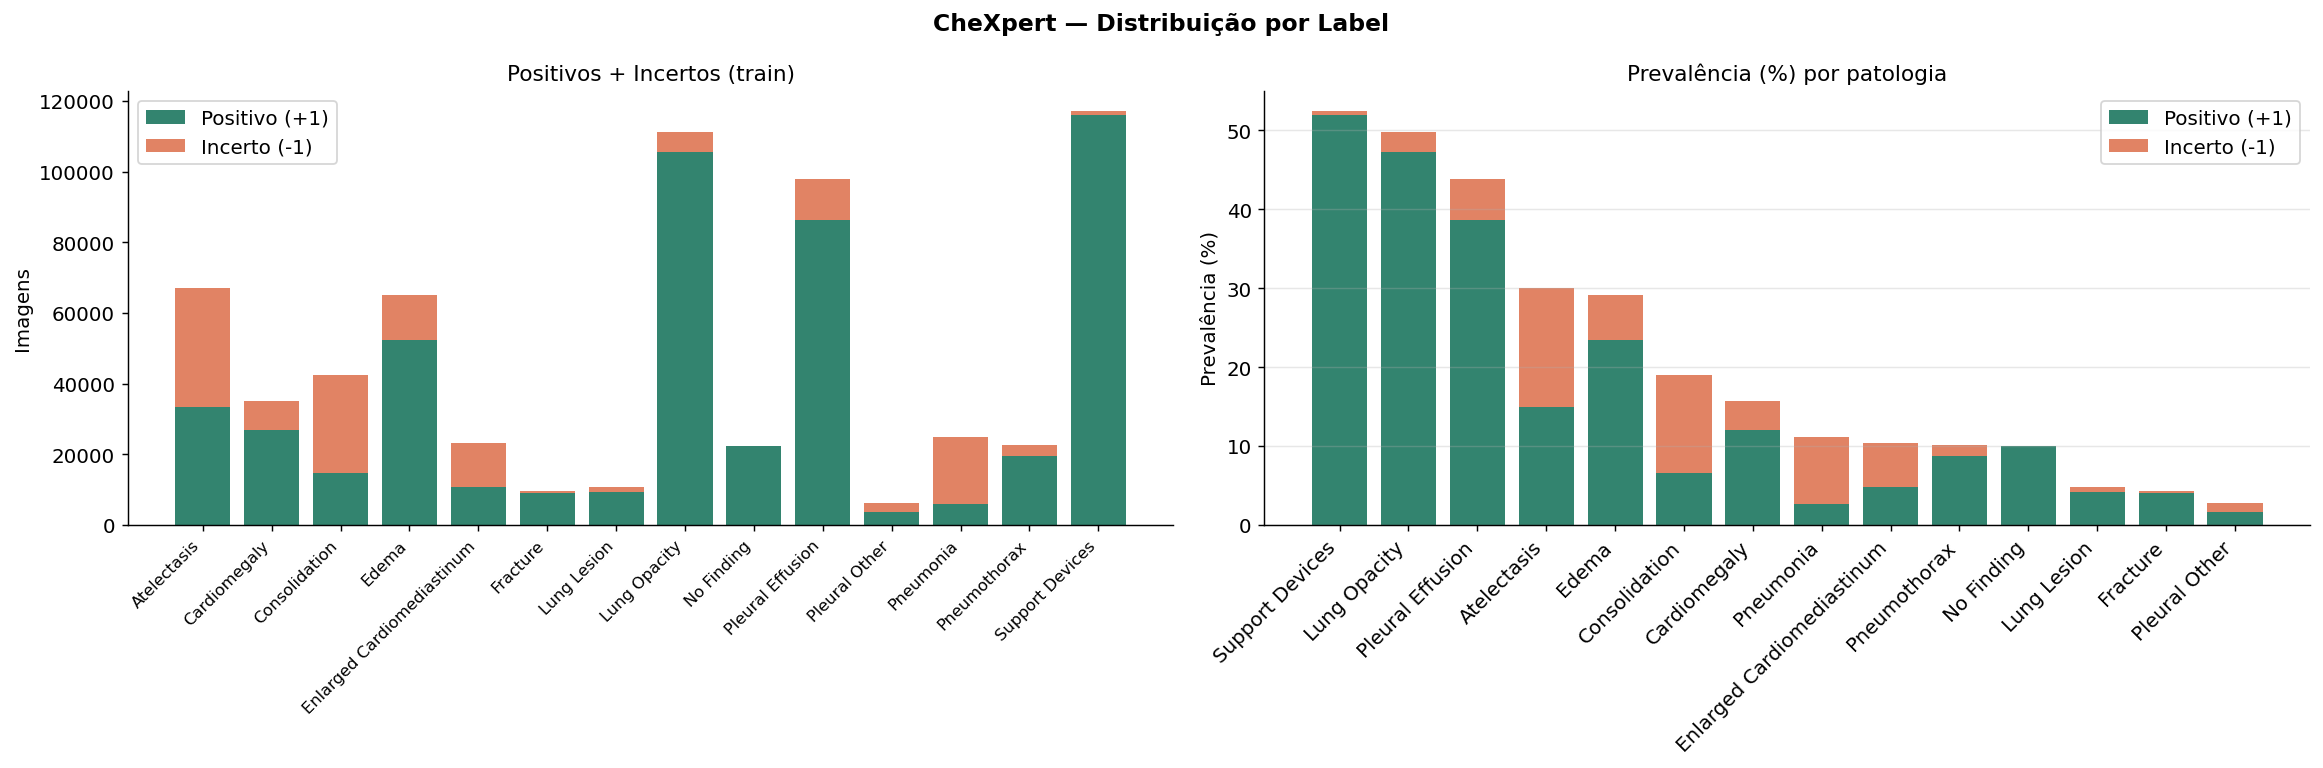

  Salvo: MyDrive/Results/analise_CheXpert/plots/sec02_label_distribution.png


In [ ]:
section('SEÇÃO 2 — Distribuição por Label (CheXpert)')

chex_tern = {}
for lbl in CHEX_LABELS:
    if lbl in df_chex_train.columns:
        chex_tern[lbl] = {
            'pos': int((df_chex_train[lbl] == 1).sum()),
            'neg': int((df_chex_train[lbl] == 0).sum()),
            'unc': int((df_chex_train[lbl] == -1).sum()),
            'nan': int(df_chex_train[lbl].isna().sum()),
        }

log(f'CheXpert — Distribuição ternária (train, {len(df_chex_train):,} imagens):')
log(f'{"Label":<35} {"Pos (+1)":>10} {"Neg (0)":>10} {"Unc (-1)":>10} {"NaN":>8}')
log('-' * 75)
for lbl, v in chex_tern.items():
    log(f'{lbl:<35} {v["pos"]:>10,} {v["neg"]:>10,} {v["unc"]:>10,} {v["nan"]:>8,}')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('CheXpert — Distribuição por Label', fontsize=13, fontweight='bold')

lbls = list(chex_tern.keys())
pos_v = [chex_tern[l]['pos'] for l in lbls]
unc_v = [chex_tern[l]['unc'] for l in lbls]
x = range(len(lbls))
axes[0].bar(x, pos_v, label='Positivo (+1)', color=C_CHEX, alpha=0.85)
axes[0].bar(x, unc_v, bottom=pos_v, label='Incerto (-1)', color=C_WARN, alpha=0.75)
axes[0].set_xticks(x); axes[0].set_xticklabels(lbls, rotation=45, ha='right', fontsize=9)
axes[0].set_title('Positivos + Incertos (train)'); axes[0].set_ylabel('Imagens'); axes[0].legend()

pos_pct = {l: v['pos']/len(df_chex_train)*100 for l, v in chex_tern.items()}
unc_pct = {l: v['unc']/len(df_chex_train)*100 for l, v in chex_tern.items()}
sorted_lbls = sorted(pos_pct, key=lambda l: -(pos_pct[l]+unc_pct[l]))
axes[1].bar(sorted_lbls, [pos_pct[l] for l in sorted_lbls], label='Positivo (+1)', color=C_CHEX, alpha=0.85)
axes[1].bar(sorted_lbls, [unc_pct[l] for l in sorted_lbls],
            bottom=[pos_pct[l] for l in sorted_lbls], label='Incerto (-1)', color=C_WARN, alpha=0.75)
axes[1].set_title('Prevalência (%) por patologia')
axes[1].set_ylabel('Prevalência (%)')
plt.sca(axes[1]); plt.xticks(rotation=45, ha='right'); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

save_fig(fig, f'{PLOTS_CHEX}/sec02_label_distribution.png')
pd.DataFrame(chex_tern).T.to_csv(f'{TABLES_DIR}/02_chex_ternary.csv')

---
# SEÇÃO 3 — Frontal vs Lateral


SEÇÃO 3 — Frontal vs Lateral (CheXpert)
Distribuição geral:
  Frontal     : 191,229 (85.5%)
  Lateral     : 32,419 (14.5%)

Por split:
split  view_type
train  Frontal      191027
       Lateral       32387
valid  Frontal         202
       Lateral          32

Prevalência por patologia × visão (train, positivos):


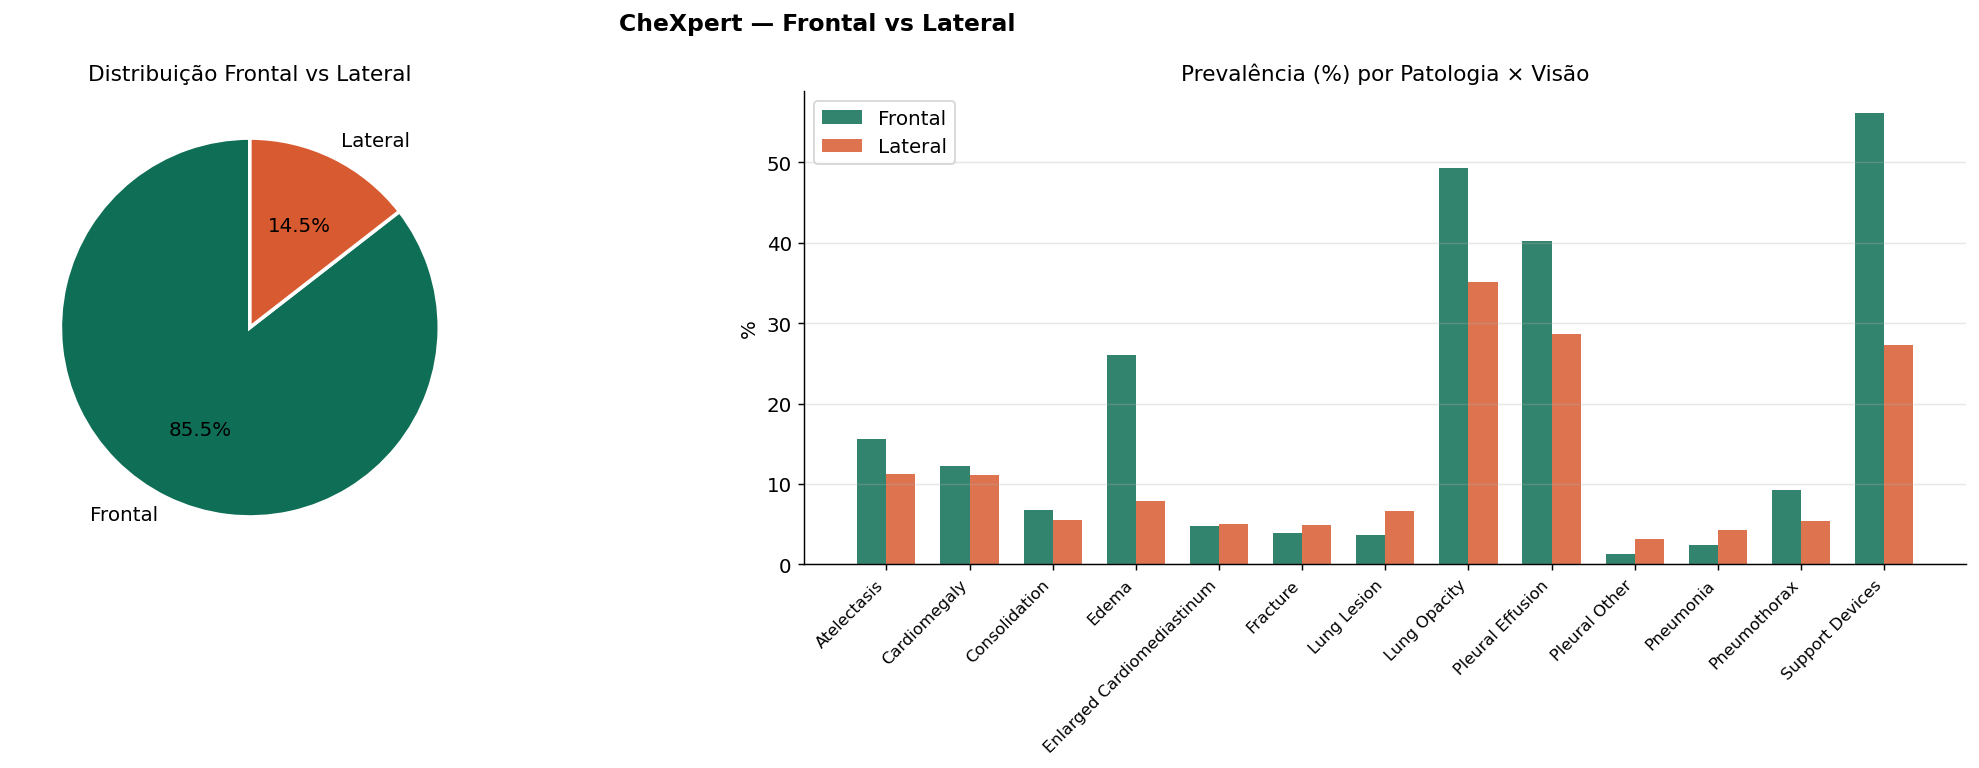

  Salvo: MyDrive/Results/analise_CheXpert/plots/sec03_frontal_vs_lateral.png

AP vs PA (train):
AP/PA
AP     161590
NaN     32387
PA      29420
LL         16
RL          1


In [ ]:
section('SEÇÃO 3 — Frontal vs Lateral (CheXpert)')

view_counts = df_chex['view_type'].value_counts()
log('Distribuição geral:')
for vt, cnt in view_counts.items():
    log(f'  {vt:<12}: {cnt:,} ({cnt/len(df_chex)*100:.1f}%)')

log('\nPor split:')
log(df_chex.groupby(['split','view_type']).size().to_string())

results_view = []
log('\nPrevalência por patologia × visão (train, positivos):')
for lbl in CHEX_LABELS_NO_NF:
    if lbl in df_chex_train.columns:
        for vt in ['Frontal', 'Lateral']:
            sub = df_chex_train[df_chex_train['view_type']==vt]
            if len(sub) > 0:
                prev = (sub[lbl]==1).mean()*100
                results_view.append({'label': lbl, 'view': vt, 'prevalencia_pct': round(prev, 2), 'n': len(sub)})

df_view = pd.DataFrame(results_view)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('CheXpert — Frontal vs Lateral', fontsize=13, fontweight='bold')

axes[0].pie(view_counts.values, labels=view_counts.index, autopct='%1.1f%%',
            colors=[C_CHEX, C_WARN], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Distribuição Frontal vs Lateral')

if not df_view.empty:
    pivot = df_view.pivot(index='label', columns='view', values='prevalencia_pct').fillna(0)
    x = np.arange(len(pivot)); w = 0.35
    if 'Frontal' in pivot.columns:
        axes[1].bar(x-w/2, pivot['Frontal'], w, label='Frontal', color=C_CHEX, alpha=0.85)
    if 'Lateral' in pivot.columns:
        axes[1].bar(x+w/2, pivot['Lateral'], w, label='Lateral', color=C_WARN, alpha=0.85)
    axes[1].set_xticks(x); axes[1].set_xticklabels(pivot.index, rotation=45, ha='right', fontsize=9)
    axes[1].set_title('Prevalência (%) por Patologia × Visão')
    axes[1].set_ylabel('%'); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

save_fig(fig, f'{PLOTS_CHEX}/sec03_frontal_vs_lateral.png')
df_view.to_csv(f'{TABLES_DIR}/03_frontal_lateral_prevalence.csv', index=False)

if 'AP/PA' in df_chex_train.columns:
    ap_pa = df_chex_train['AP/PA'].value_counts(dropna=False)
    log('\nAP vs PA (train):')
    log(ap_pa.to_string())

---
# SEÇÃO 4 — Desbalanceamento


SEÇÃO 4 — Desbalanceamento (CheXpert)
CheXpert — Imbalance ratio (negativos:positivos, U-Ignore):
  Pleural Other                           62.4:1  (3,523 pos)
  Pneumonia                               36.0:1  (6,039 pos)
  Fracture                                23.7:1  (9,040 pos)
  Lung Lesion                             23.3:1  (9,186 pos)
  Enlarged Cardiomediastinum              19.7:1  (10,798 pos)
  Consolidation                           14.1:1  (14,783 pos)
  Pneumothorax                            10.5:1  (19,448 pos)
  No Finding                               9.0:1  (22,381 pos)
  Cardiomegaly                             7.3:1  (27,000 pos)
  Atelectasis                              5.7:1  (33,376 pos)
  Edema                                    3.3:1  (52,246 pos)
  Pleural Effusion                         1.6:1  (86,187 pos)
  Lung Opacity                             1.1:1  (105,581 pos)
  Support Devices                          0.9:1  (116,001 pos)

Label mais frequente

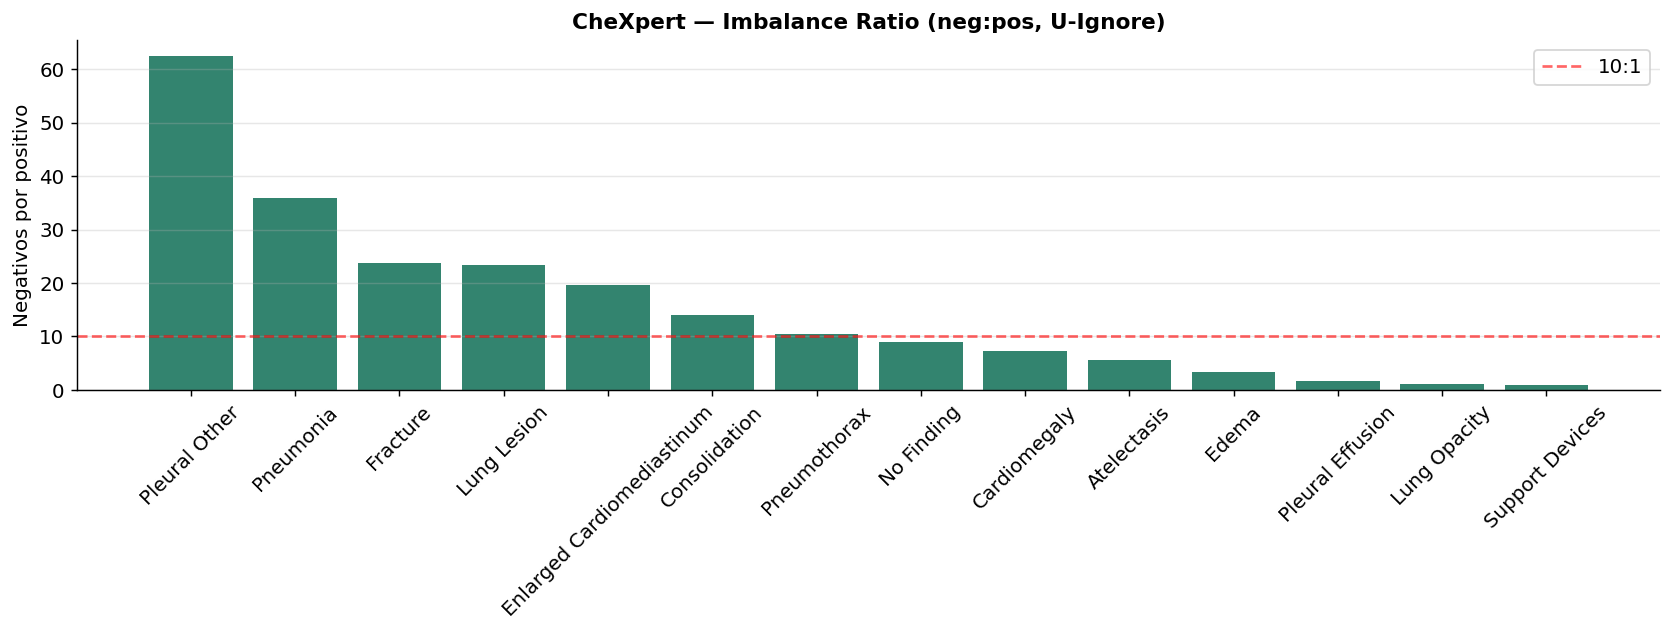

  Salvo: MyDrive/Results/analise_CheXpert/plots/sec04_imbalance_ratio.png


In [ ]:
section('SEÇÃO 4 — Desbalanceamento (CheXpert)')

chex_ratio = {l: (len(df_chex_train)-v['pos'])/v['pos'] if v['pos']>0 else None
              for l, v in chex_tern.items()}
chex_ratio_clean = {l: v for l, v in chex_ratio.items() if v is not None}
sorted_chex = sorted(chex_ratio_clean, key=lambda l: -chex_ratio_clean[l])

max_c = max((l for l in chex_tern if chex_tern[l]['pos']>0), key=lambda l: chex_tern[l]['pos'])
min_c = min((l for l in chex_tern if chex_tern[l]['pos']>0), key=lambda l: chex_tern[l]['pos'])

log('CheXpert — Imbalance ratio (negativos:positivos, U-Ignore):')
for lbl in sorted_chex:
    log(f'  {lbl:<35} {chex_ratio_clean[lbl]:>8.1f}:1  ({chex_tern[lbl]["pos"]:,} pos)')

log(f'\nLabel mais frequente : {max_c} ({chex_tern[max_c]["pos"]:,})')
log(f'Label menos frequente: {min_c} ({chex_tern[min_c]["pos"]:,})')
log(f'Razão max/min        : {chex_tern[max_c]["pos"]/chex_tern[min_c]["pos"]:.1f}×')

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(sorted_chex, [chex_ratio_clean[l] for l in sorted_chex], color=C_CHEX, alpha=0.85)
ax.set_title('CheXpert — Imbalance Ratio (neg:pos, U-Ignore)', fontweight='bold')
ax.set_ylabel('Negativos por positivo')
ax.tick_params(axis='x', rotation=45)
ax.axhline(10, color='red', linestyle='--', alpha=0.6, label='10:1')
ax.legend(); ax.grid(axis='y', alpha=0.3)
save_fig(fig, f'{PLOTS_CHEX}/sec04_imbalance_ratio.png')
pd.DataFrame({'imbalance_ratio': chex_ratio_clean}).to_csv(f'{TABLES_DIR}/04_chex_imbalance.csv')

---
# SEÇÃO 6 — Impacto U-Ones vs U-Ignore


SEÇÃO 6 — Impacto U-Ones vs U-Ignore (CheXpert)
Label                                   U-Ignore       U-Ones      Ganho    Ganho %
--------------------------------------------------------------------------------
Atelectasis                               33,376       67,115    +33,739     101.1%
Cardiomegaly                              27,000       35,087     +8,087      30.0%
Consolidation                             14,783       42,525    +27,742     187.7%
Edema                                     52,246       65,230    +12,984      24.9%
Enlarged Cardiomediastinum                10,798       23,201    +12,403     114.9%
Fracture                                   9,040        9,682       +642       7.1%
Lung Lesion                                9,186       10,674     +1,488      16.2%
Lung Opacity                             105,581      111,179     +5,598       5.3%
No Finding                                22,381       22,381         +0       0.0%
Pleural Effusion              

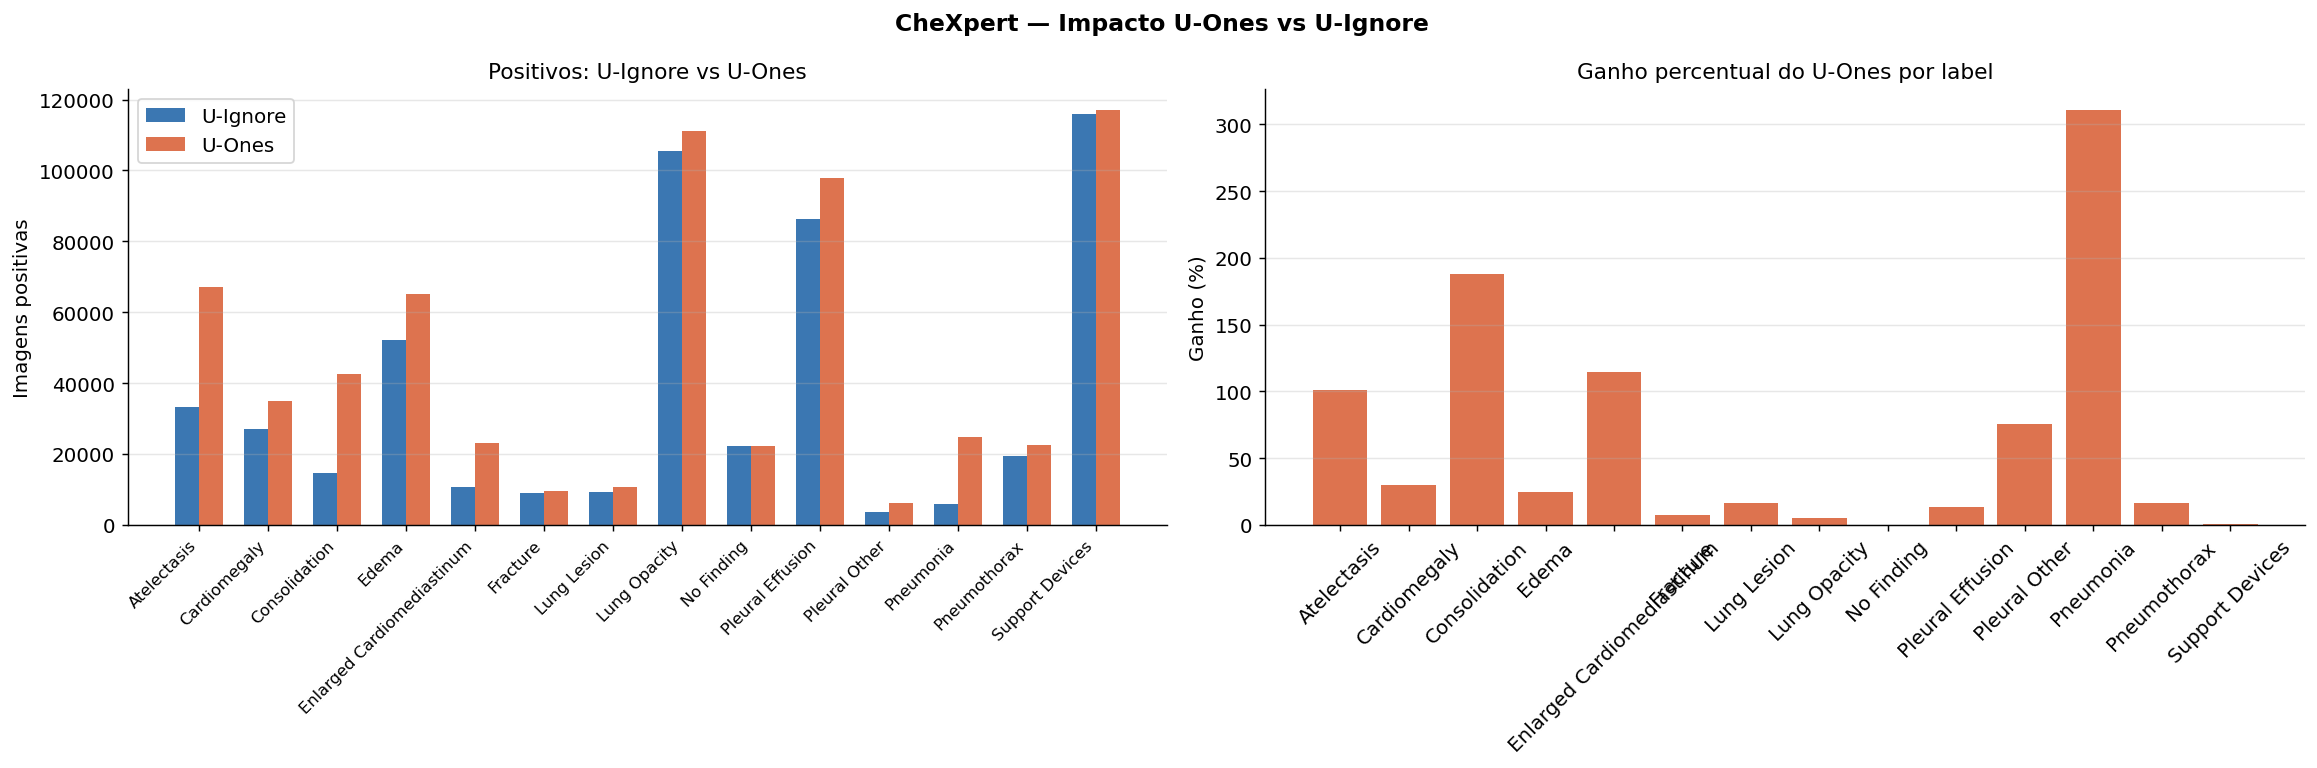

  Salvo: MyDrive/Results/analise_CheXpert/plots/sec06_uones_vs_uignore.png


In [ ]:
section('SEÇÃO 6 — Impacto U-Ones vs U-Ignore (CheXpert)')

log(f'{"Label":<35} {"U-Ignore":>12} {"U-Ones":>12} {"Ganho":>10} {"Ganho %":>10}')
log('-' * 80)

uones_data = []
total_ui = total_uo = 0
for lbl, v in chex_tern.items():
    ui = v['pos']; uo = v['pos'] + v['unc']
    g = uo - ui; gp = (g/ui*100) if ui > 0 else 0
    total_ui += ui; total_uo += uo
    log(f'{lbl:<35} {ui:>12,} {uo:>12,} {g:>+10,} {gp:>9.1f}%')
    uones_data.append({'label': lbl, 'u_ignore': ui, 'u_ones': uo, 'ganho': g, 'ganho_pct': gp})

log('-' * 80)
log(f'{"TOTAL":<35} {total_ui:>12,} {total_uo:>12,} {total_uo-total_ui:>+10,} {(total_uo-total_ui)/total_ui*100:>9.1f}%')

df_uones = pd.DataFrame(uones_data)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('CheXpert — Impacto U-Ones vs U-Ignore', fontsize=13, fontweight='bold')

x = np.arange(len(df_uones)); w = 0.35
axes[0].bar(x-w/2, df_uones['u_ignore'], w, label='U-Ignore', color=C_NIH,  alpha=0.85)
axes[0].bar(x+w/2, df_uones['u_ones'],   w, label='U-Ones',   color=C_WARN, alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(df_uones['label'], rotation=45, ha='right', fontsize=9)
axes[0].set_title('Positivos: U-Ignore vs U-Ones'); axes[0].set_ylabel('Imagens positivas'); axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(df_uones['label'], df_uones['ganho_pct'], color=C_WARN, alpha=0.85)
axes[1].set_title('Ganho percentual do U-Ones por label'); axes[1].set_ylabel('Ganho (%)')
axes[1].tick_params(axis='x', rotation=45); axes[1].grid(axis='y', alpha=0.3)

save_fig(fig, f'{PLOTS_CHEX}/sec06_uones_vs_uignore.png')
df_uones.to_csv(f'{TABLES_DIR}/06_uones_impact.csv', index=False)

---
# SEÇÃO 7 — Complexidade Multi-Label


SEÇÃO 7 — Complexidade Multi-Label (CheXpert)
CheXpert — Labels por imagem (U-Ignore, excl. No Finding):
  0.0 labels: 24,714 imagens (11.1%)
  1.0 labels: 48,013 imagens (21.5%)
  2.0 labels: 57,296 imagens (25.6%)
  3.0 labels: 54,151 imagens (24.2%)
  4.0 labels: 29,550 imagens (13.2%)
  5.0 labels: 8,333 imagens (3.7%)
  6.0 labels: 1,224 imagens (0.5%)
  7.0 labels: 123 imagens (0.1%)
  8.0 labels: 10 imagens (0.0%)
  Média: 2.21 | Mediana: 2.0 | Max: 8


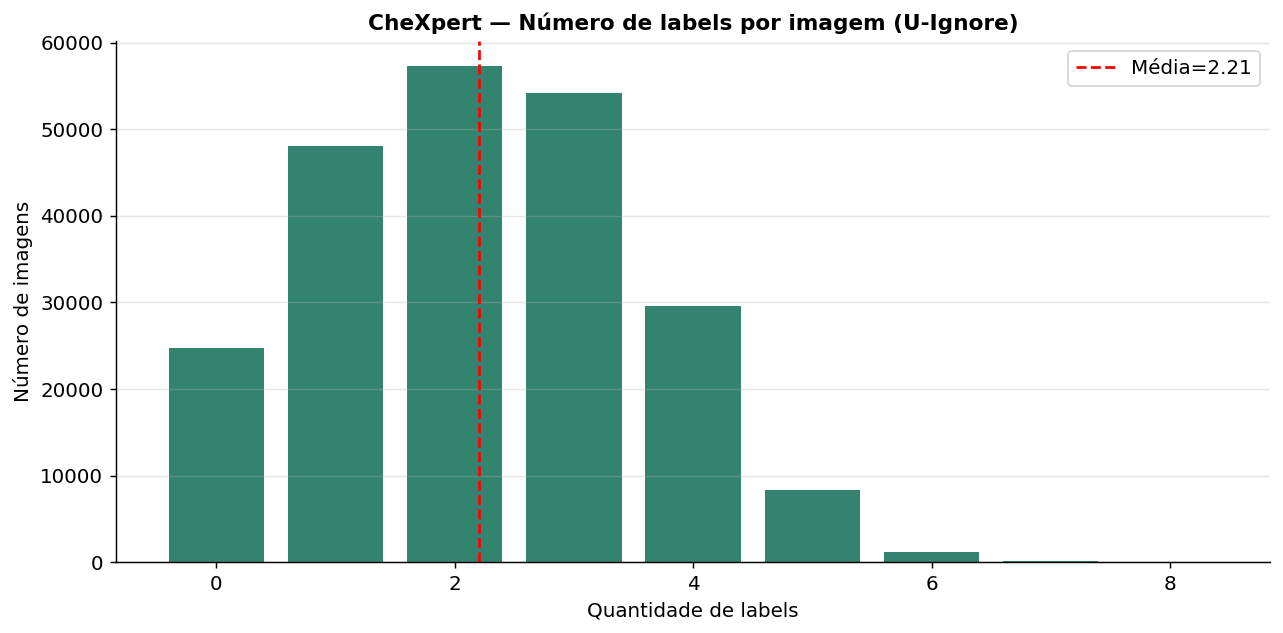

  Salvo: MyDrive/Results/analise_CheXpert/plots/sec07_multilabel_complexity.png


In [ ]:
section('SEÇÃO 7 — Complexidade Multi-Label (CheXpert)')

chex_bin = df_chex_train[CHEX_LABELS_NO_NF].fillna(0).clip(lower=0)
chex_n_labels = chex_bin.sum(axis=1)
chex_label_dist = chex_n_labels.value_counts().sort_index()

log('CheXpert — Labels por imagem (U-Ignore, excl. No Finding):')
for n, cnt in chex_label_dist.items():
    log(f'  {n} labels: {cnt:,} imagens ({cnt/len(df_chex_train)*100:.1f}%)')
log(f'  Média: {chex_n_labels.mean():.2f} | Mediana: {chex_n_labels.median():.1f} | Max: {int(chex_n_labels.max())}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(chex_label_dist.index, chex_label_dist.values, color=C_CHEX, alpha=0.85)
ax.set_title('CheXpert — Número de labels por imagem (U-Ignore)', fontweight='bold')
ax.set_xlabel('Quantidade de labels'); ax.set_ylabel('Número de imagens')
ax.axvline(chex_n_labels.mean(), color='red', linestyle='--', label=f'Média={chex_n_labels.mean():.2f}')
ax.legend(); ax.grid(axis='y', alpha=0.3)
save_fig(fig, f'{PLOTS_CHEX}/sec07_multilabel_complexity.png')

---
# SEÇÃO 8 — Combinações de Labels Mais Frequentes


SEÇÃO 8 — Combinações de Labels Mais Frequentes (CheXpert)
CheXpert — Todas as combinações de labels (1,451 combinações únicas):
     1. Lung Opacity + Pleural Effusion + Support Devices            13,088
     2. Lung Opacity + Support Devices                                9,649
     3. No Finding + Support Devices                                  8,808
     4. Lung Opacity + Pleural Effusion                               7,219
     5. Edema + Lung Opacity + Pleural Effusion + Support Devices     6,276
     6. Pleural Effusion + Support Devices                            4,329
     7. Edema + Lung Opacity + Support Devices                        4,264
     8. Edema + Support Devices                                       3,775
     9. Edema + Pleural Effusion + Support Devices                    2,690
    10. Atelectasis + Support Devices                                 2,620
    11. Edema + Lung Opacity + Pleural Effusion                       2,528
    12. Atelectasis + Pleural Effu

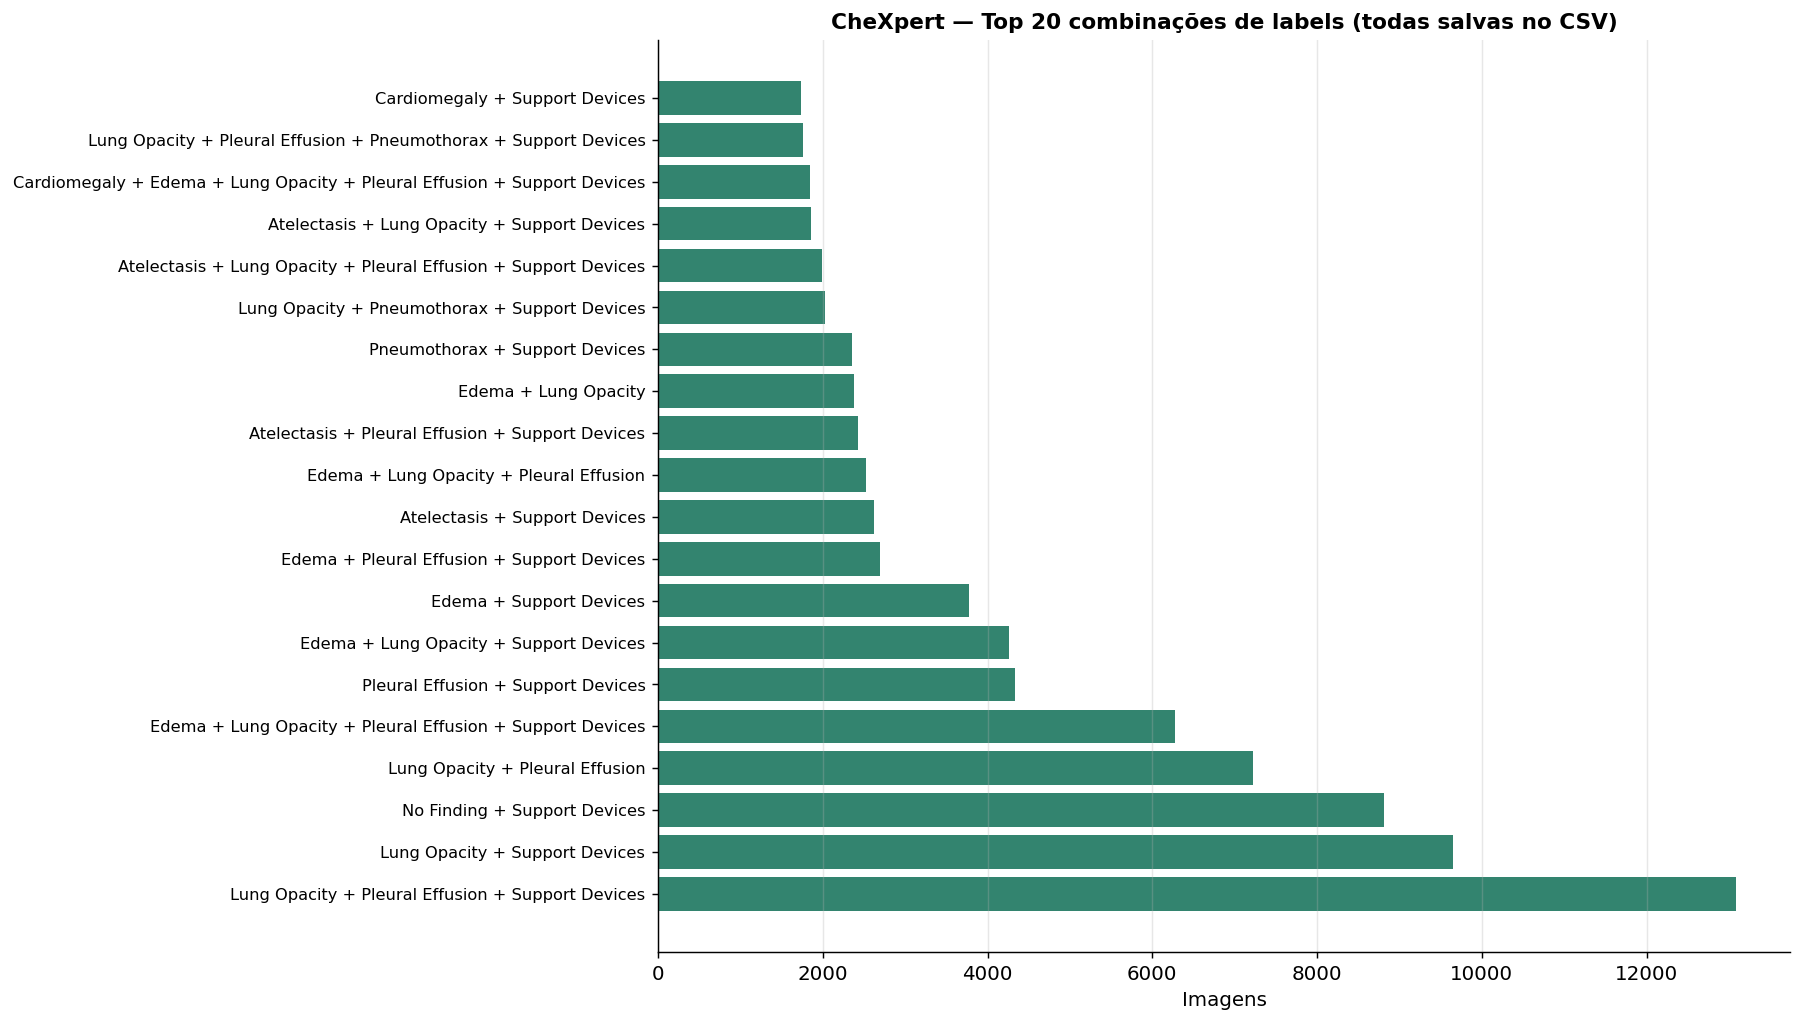

  Salvo: MyDrive/Results/analise_CheXpert/plots/sec08_label_combinations.png

  CSV completo salvo: MyDrive/Results/analise_CheXpert/tabelas/08_chex_combos_completo.csv


In [ ]:
section('SEÇÃO 8 — Combinações de Labels Mais Frequentes (CheXpert)')

def all_combinations(df, labels):
    combos = Counter()
    for _, row in df[labels].fillna(0).clip(lower=0).iterrows():
        active = tuple(sorted([l for l in labels if row[l] == 1]))
        if len(active) > 1:
            combos[active] += 1
    return combos.most_common()  # sem limite

chex_combos = all_combinations(df_chex_train, CHEX_LABELS)
log(f'CheXpert — Todas as combinações de labels ({len(chex_combos):,} combinações únicas):')
for i, (combo, cnt) in enumerate(chex_combos, 1):
    log(f'  {i:>4}. {" + ".join(combo):<60} {cnt:>6,}')

# Plot: top 20 para visualização (todas vão pro CSV)
fig, ax = plt.subplots(figsize=(14, 8))
labels_str = [' + '.join(c) for c, _ in chex_combos[:20]]
counts     = [v for _, v in chex_combos[:20]]
ax.barh(range(len(labels_str)), counts, color=C_CHEX, alpha=0.85)
ax.set_yticks(range(len(labels_str))); ax.set_yticklabels(labels_str, fontsize=9)
ax.set_title('CheXpert — Top 20 combinações de labels (todas salvas no CSV)', fontweight='bold')
ax.set_xlabel('Imagens'); ax.grid(axis='x', alpha=0.3)
save_fig(fig, f'{PLOTS_CHEX}/sec08_label_combinations.png')

pd.DataFrame([('+'.join(c), v) for c, v in chex_combos], columns=['combo', 'count']).to_csv(
    f'{TABLES_DIR}/08_chex_combos_completo.csv', index=False)
log(f'\n  CSV completo salvo: {TABLES_DIR.replace(BASE_DRIVE, "MyDrive")}/08_chex_combos_completo.csv')

---
# SEÇÃO 9 — No Finding vs Com Patologia


SEÇÃO 9 — No Finding vs Com Patologia (CheXpert)
CheXpert train:
  No Finding    : 22,381 (10.0%)
  Com patologia : 201,033 (90.0%)

CheXpert — Complexidade de patologias (excl. No Finding):
  Sem patologia    : 24,714 (11.1%)
  1 patologia      : 48,013 (21.5%)
  2+ patologias    : 150,687 (67.4%)


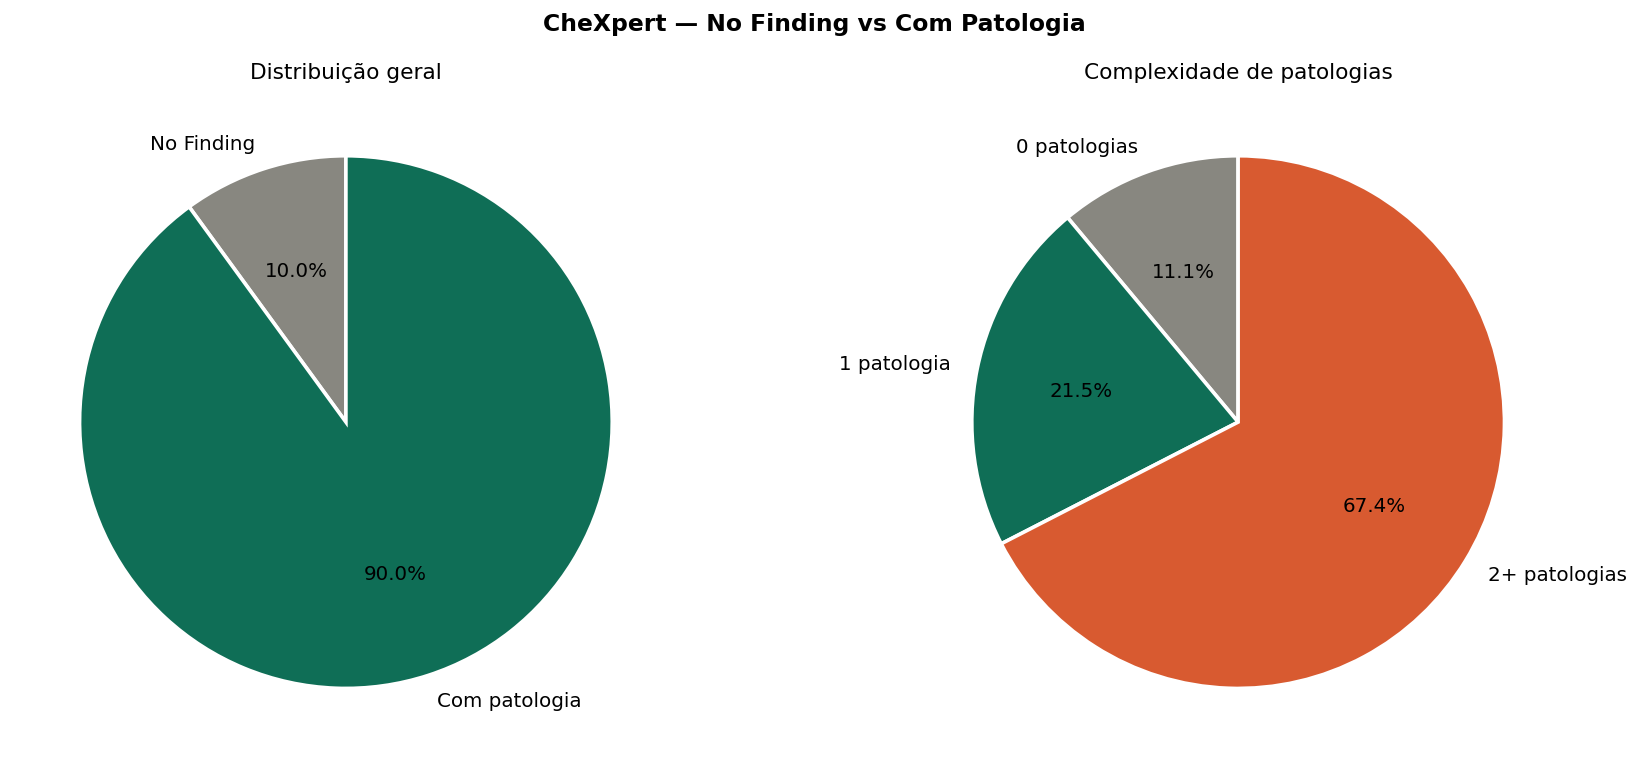

  Salvo: MyDrive/Results/analise_CheXpert/plots/sec09_no_finding.png


In [ ]:
section('SEÇÃO 9 — No Finding vs Com Patologia (CheXpert)')

chex_nf = 0; chex_has = 0
if 'No Finding' in df_chex_train.columns:
    chex_nf  = (df_chex_train['No Finding'] == 1).sum()
    chex_has = len(df_chex_train) - chex_nf

log('CheXpert train:')
log(f'  No Finding    : {chex_nf:,} ({chex_nf/len(df_chex_train)*100:.1f}%)')
log(f'  Com patologia : {chex_has:,} ({chex_has/len(df_chex_train)*100:.1f}%)')

chex_bin = df_chex_train[CHEX_LABELS_NO_NF].fillna(0).clip(lower=0)
n_labels = chex_bin.sum(axis=1)
only_one   = (n_labels == 1).sum()
multi_path = (n_labels > 1).sum()
zero_path  = (n_labels == 0).sum()

log(f'\nCheXpert — Complexidade de patologias (excl. No Finding):')
log(f'  Sem patologia    : {zero_path:,} ({zero_path/len(df_chex_train)*100:.1f}%)')
log(f'  1 patologia      : {only_one:,} ({only_one/len(df_chex_train)*100:.1f}%)')
log(f'  2+ patologias    : {multi_path:,} ({multi_path/len(df_chex_train)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('CheXpert — No Finding vs Com Patologia', fontsize=13, fontweight='bold')

axes[0].pie([chex_nf, chex_has], labels=['No Finding','Com patologia'],
            autopct='%1.1f%%', colors=[C_GRAY, C_CHEX],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Distribuição geral')

axes[1].pie([zero_path, only_one, multi_path],
            labels=['0 patologias','1 patologia','2+ patologias'],
            autopct='%1.1f%%', colors=[C_GRAY, C_CHEX, C_WARN],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Complexidade de patologias')

save_fig(fig, f'{PLOTS_CHEX}/sec09_no_finding.png')

---
# SEÇÃO 10 — Demografias: Sexo por Patologia


SEÇÃO 10 — Demografias: Sexo por Patologia (CheXpert)
Distribuição geral de sexo (CheXpert train):
  Male: 132,636 (59.4%)
  Female: 90,777 (40.6%)
  Unknown: 1 (0.0%)

Label                                  Masculino %     Feminino %
-----------------------------------------------------------------
Atelectasis                                 15.27%         14.46%
Cardiomegaly                                12.42%         11.59%
Consolidation                                6.57%          6.68%
Edema                                       22.67%         24.43%
Enlarged Cardiomediastinum                   5.15%          4.36%
Fracture                                     4.47%          3.42%
Lung Lesion                                  4.05%          4.20%
Lung Opacity                                47.01%         47.63%
Pleural Effusion                            38.43%         38.79%
Pleural Other                                1.68%          1.42%
Pneumonia                             

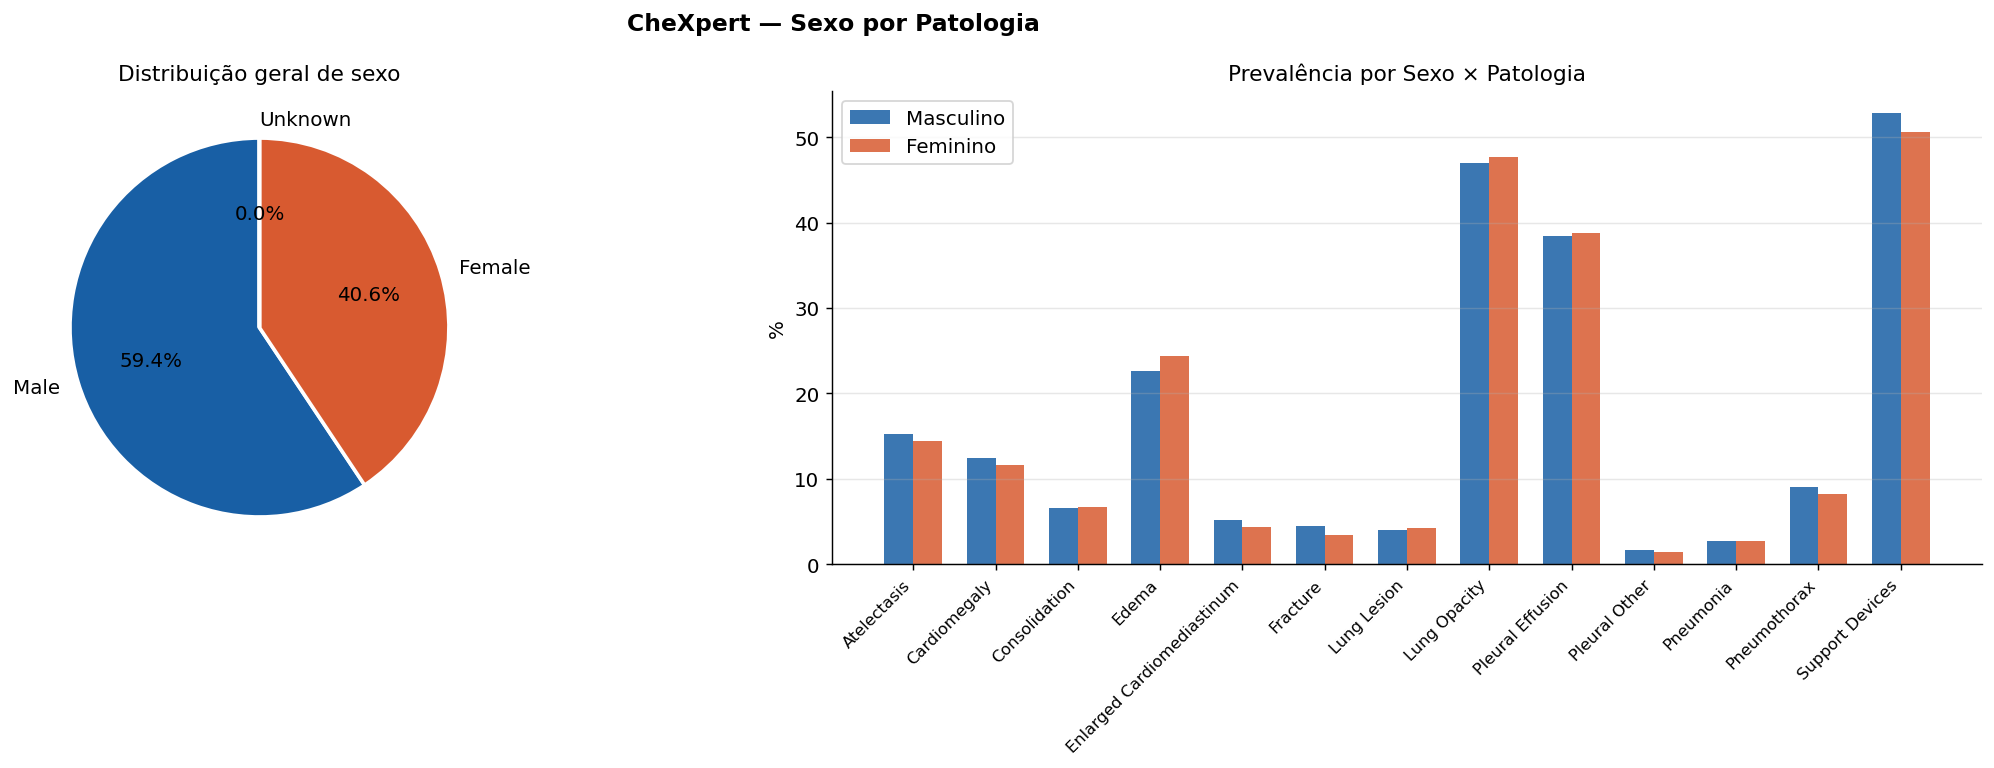

  Salvo: MyDrive/Results/analise_CheXpert/plots/sec10_sex_by_pathology.png


In [ ]:
section('SEÇÃO 10 — Demografias: Sexo por Patologia (CheXpert)')

if 'Sex' not in df_chex_train.columns:
    log('Coluna Sex não encontrada no CheXpert.')
else:
    sex_dist = df_chex_train['Sex'].value_counts(dropna=False)
    log('Distribuição geral de sexo (CheXpert train):')
    for s, cnt in sex_dist.items():
        log(f'  {s}: {cnt:,} ({cnt/len(df_chex_train)*100:.1f}%)')

    sex_data = []
    log(f'\n{"Label":<35} {"Masculino %":>14} {"Feminino %":>14}')
    log('-' * 65)
    for lbl in CHEX_LABELS_NO_NF:
        if lbl not in df_chex_train.columns: continue
        for sex in ['Male','Female']:
            sub = df_chex_train[df_chex_train['Sex']==sex]
            if len(sub) > 0:
                prev = (sub[lbl]==1).mean()*100
                sex_data.append({'label': lbl, 'sex': sex, 'prevalencia_pct': round(prev, 2)})

    df_sex = pd.DataFrame(sex_data)
    if not df_sex.empty:
        pivot_sex = df_sex.pivot(index='label', columns='sex', values='prevalencia_pct').fillna(0)
        for lbl in pivot_sex.index:
            m = pivot_sex.loc[lbl,'Male']   if 'Male'   in pivot_sex.columns else 0
            f = pivot_sex.loc[lbl,'Female'] if 'Female' in pivot_sex.columns else 0
            log(f'{lbl:<35} {m:>13.2f}% {f:>13.2f}%')

        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        fig.suptitle('CheXpert — Sexo por Patologia', fontsize=13, fontweight='bold')

        axes[0].pie(sex_dist.values, labels=sex_dist.index, autopct='%1.1f%%',
                    colors=[C_NIH, C_WARN, C_GRAY], startangle=90,
                    wedgeprops={'edgecolor':'white','linewidth':2})
        axes[0].set_title('Distribuição geral de sexo')

        x = np.arange(len(pivot_sex)); w = 0.35
        if 'Male' in pivot_sex.columns:
            axes[1].bar(x-w/2, pivot_sex['Male'],   w, label='Masculino', color=C_NIH,  alpha=0.85)
        if 'Female' in pivot_sex.columns:
            axes[1].bar(x+w/2, pivot_sex['Female'], w, label='Feminino',  color=C_WARN, alpha=0.85)
        axes[1].set_xticks(x); axes[1].set_xticklabels(pivot_sex.index, rotation=45, ha='right', fontsize=9)
        axes[1].set_title('Prevalência por Sexo × Patologia')
        axes[1].set_ylabel('%'); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

        save_fig(fig, f'{PLOTS_CHEX}/sec10_sex_by_pathology.png')
        df_sex.to_csv(f'{TABLES_DIR}/10_sex_prevalence.csv', index=False)

---
# SEÇÃO 11 — Demografias: Idade por Patologia


SEÇÃO 11 — Demografias: Idade por Patologia (CheXpert)
CheXpert — Idade: min=0 | max=90 | média=60.4 | mediana=62.0

Label                                  Média positivos    Média negativos
---------------------------------------------------------------------------
Atelectasis                                      61.6              57.6
Cardiomegaly                                     64.3              57.5
Consolidation                                    61.4              57.6
Edema                                            64.1              60.7
Enlarged Cardiomediastinum                       60.6              53.5
Fracture                                         61.4              51.4
Lung Lesion                                      61.9              57.3
Lung Opacity                                     62.3              56.3
Pleural Effusion                                 63.0              56.3
Pleural Other                                    61.4              44.5
Pneumonia   

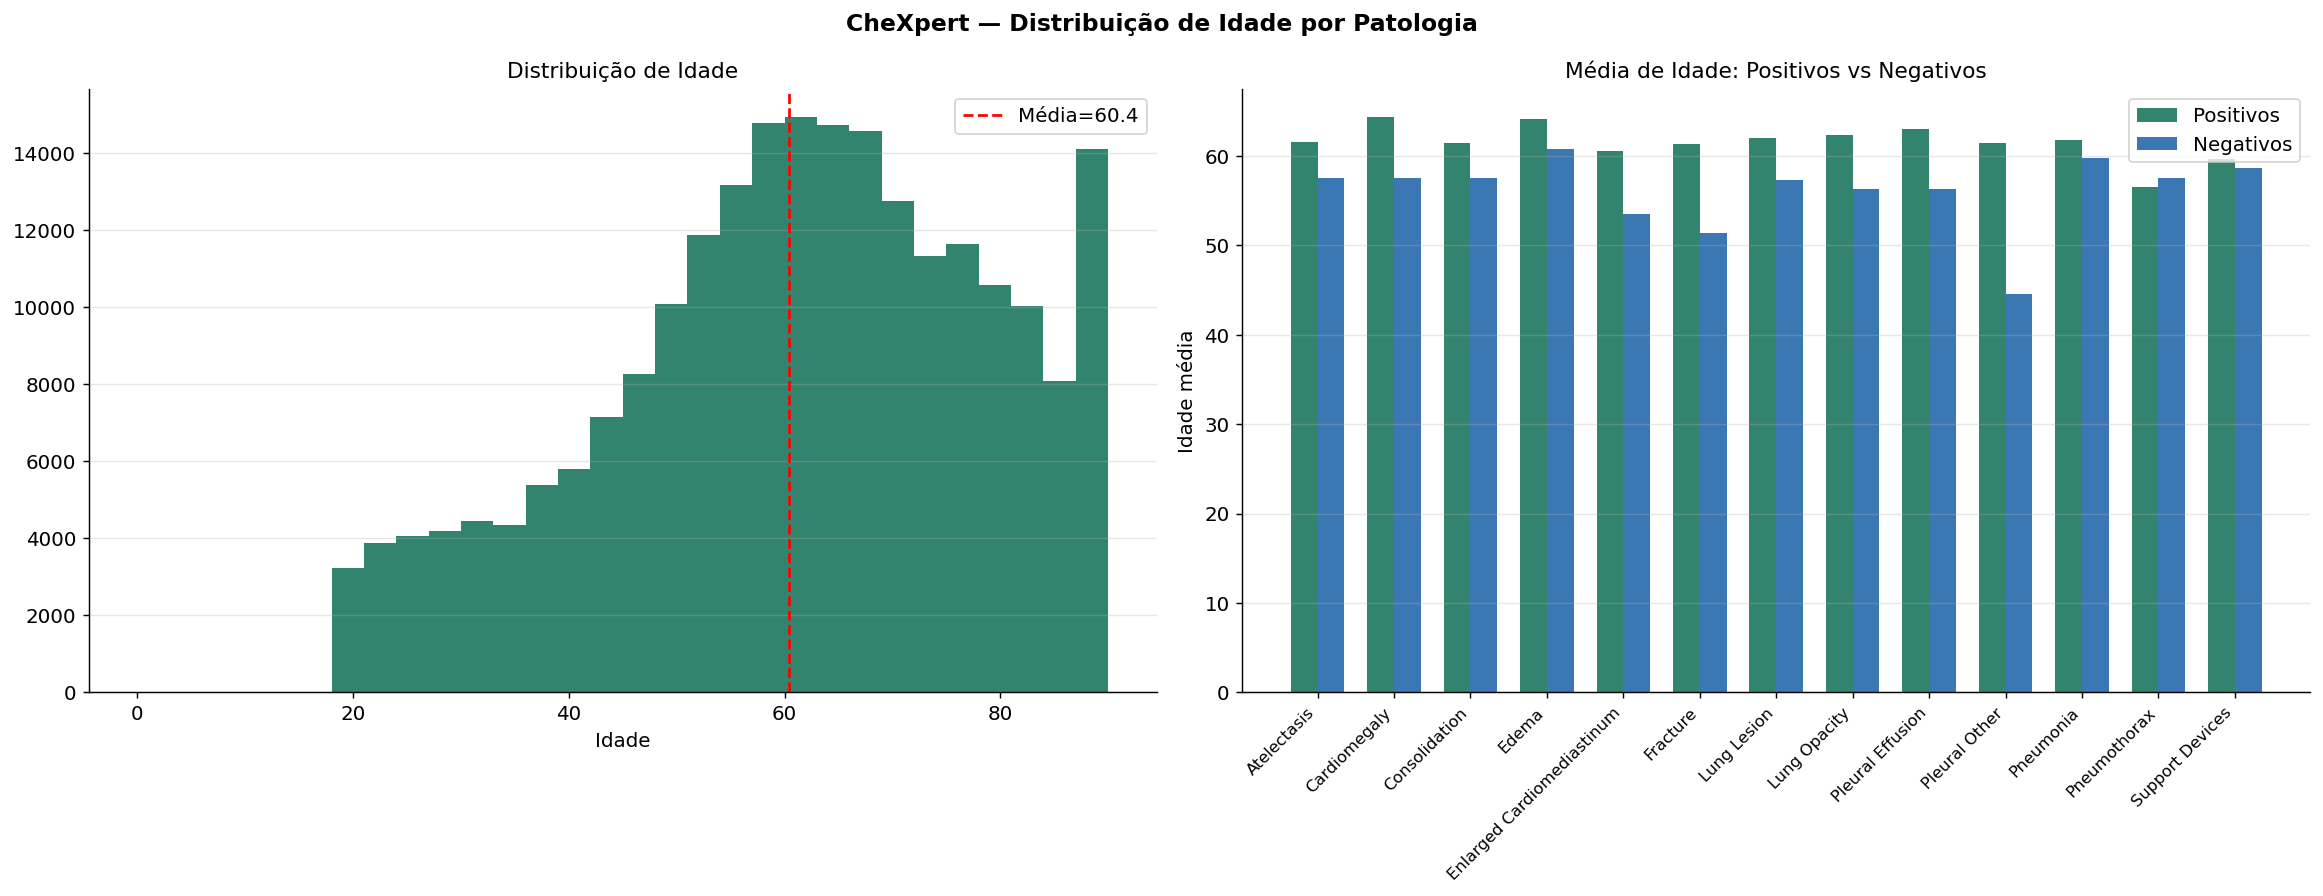

  Salvo: MyDrive/Results/analise_CheXpert/plots/sec11_age_by_pathology.png


In [ ]:
section('SEÇÃO 11 — Demografias: Idade por Patologia (CheXpert)')

age_col_chex = 'Age' if 'Age' in df_chex_train.columns else None

if not age_col_chex:
    log('Coluna de idade não encontrada no CheXpert.')
else:
    chex_age = df_chex_train[age_col_chex].dropna()
    log(f'CheXpert — Idade: min={chex_age.min():.0f} | max={chex_age.max():.0f} | média={chex_age.mean():.1f} | mediana={chex_age.median():.1f}')

    age_by_label = {}
    log(f'\n{"Label":<35} {"Média positivos":>18} {"Média negativos":>18}')
    log('-' * 75)
    for lbl in CHEX_LABELS_NO_NF:
        if lbl not in df_chex_train.columns: continue
        pos_age = df_chex_train[df_chex_train[lbl]==1][age_col_chex].dropna()
        neg_age = df_chex_train[df_chex_train[lbl]==0][age_col_chex].dropna()
        pm = pos_age.mean() if len(pos_age)>0 else None
        nm = neg_age.mean() if len(neg_age)>0 else None
        age_by_label[lbl] = {'pos_mean': pm, 'neg_mean': nm}
        if pm and nm:
            log(f'{lbl:<35} {pm:>17.1f} {nm:>17.1f}')

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle('CheXpert — Distribuição de Idade por Patologia', fontsize=13, fontweight='bold')

    axes[0].hist(chex_age, bins=30, color=C_CHEX, alpha=0.85)
    axes[0].axvline(chex_age.mean(), color='red', linestyle='--', label=f'Média={chex_age.mean():.1f}')
    axes[0].set_title('Distribuição de Idade'); axes[0].set_xlabel('Idade')
    axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

    valid_lbl = {l: v for l, v in age_by_label.items() if v['pos_mean'] and v['neg_mean']}
    if valid_lbl:
        lbls_a = list(valid_lbl.keys()); x = np.arange(len(lbls_a)); w = 0.35
        axes[1].bar(x-w/2, [valid_lbl[l]['pos_mean'] for l in lbls_a], w,
                    label='Positivos', color=C_CHEX, alpha=0.85)
        axes[1].bar(x+w/2, [valid_lbl[l]['neg_mean'] for l in lbls_a], w,
                    label='Negativos', color=C_NIH,  alpha=0.85)
        axes[1].set_xticks(x); axes[1].set_xticklabels(lbls_a, rotation=45, ha='right', fontsize=9)
        axes[1].set_title('Média de Idade: Positivos vs Negativos')
        axes[1].set_ylabel('Idade média'); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

    save_fig(fig, f'{PLOTS_CHEX}/sec11_age_by_pathology.png')
    pd.DataFrame(age_by_label).T.to_csv(f'{TABLES_DIR}/11_chex_age_by_label.csv')

---
# SEÇÃO 12 — AP vs PA por Patologia


SEÇÃO 12 — AP vs PA por Patologia (CheXpert)
Distribuição geral AP/PA:
  AP      : 161,590 (72.3%)
  nan     : 32,387 (14.5%)
  PA      : 29,420 (13.2%)
  LL      : 16 (0.0%)
  RL      : 1 (0.0%)

Label                                     AP %       PA %    Diferença
----------------------------------------------------------------------
Atelectasis                             16.41%     10.86%       +5.55%
Cardiomegaly                            12.67%      9.89%       +2.78%
Consolidation                            7.11%      5.09%       +2.02%
Edema                                   29.68%      5.81%      +23.87%
Enlarged Cardiomediastinum               4.80%      4.88%       -0.08%
Fracture                                 3.73%      4.80%       -1.07%
Lung Lesion                              3.04%      7.21%       -4.17%
Lung Opacity                            52.27%     33.09%      +19.18%
Pleural Effusion                        42.59%     27.46%      +15.13%
Pleural Other        

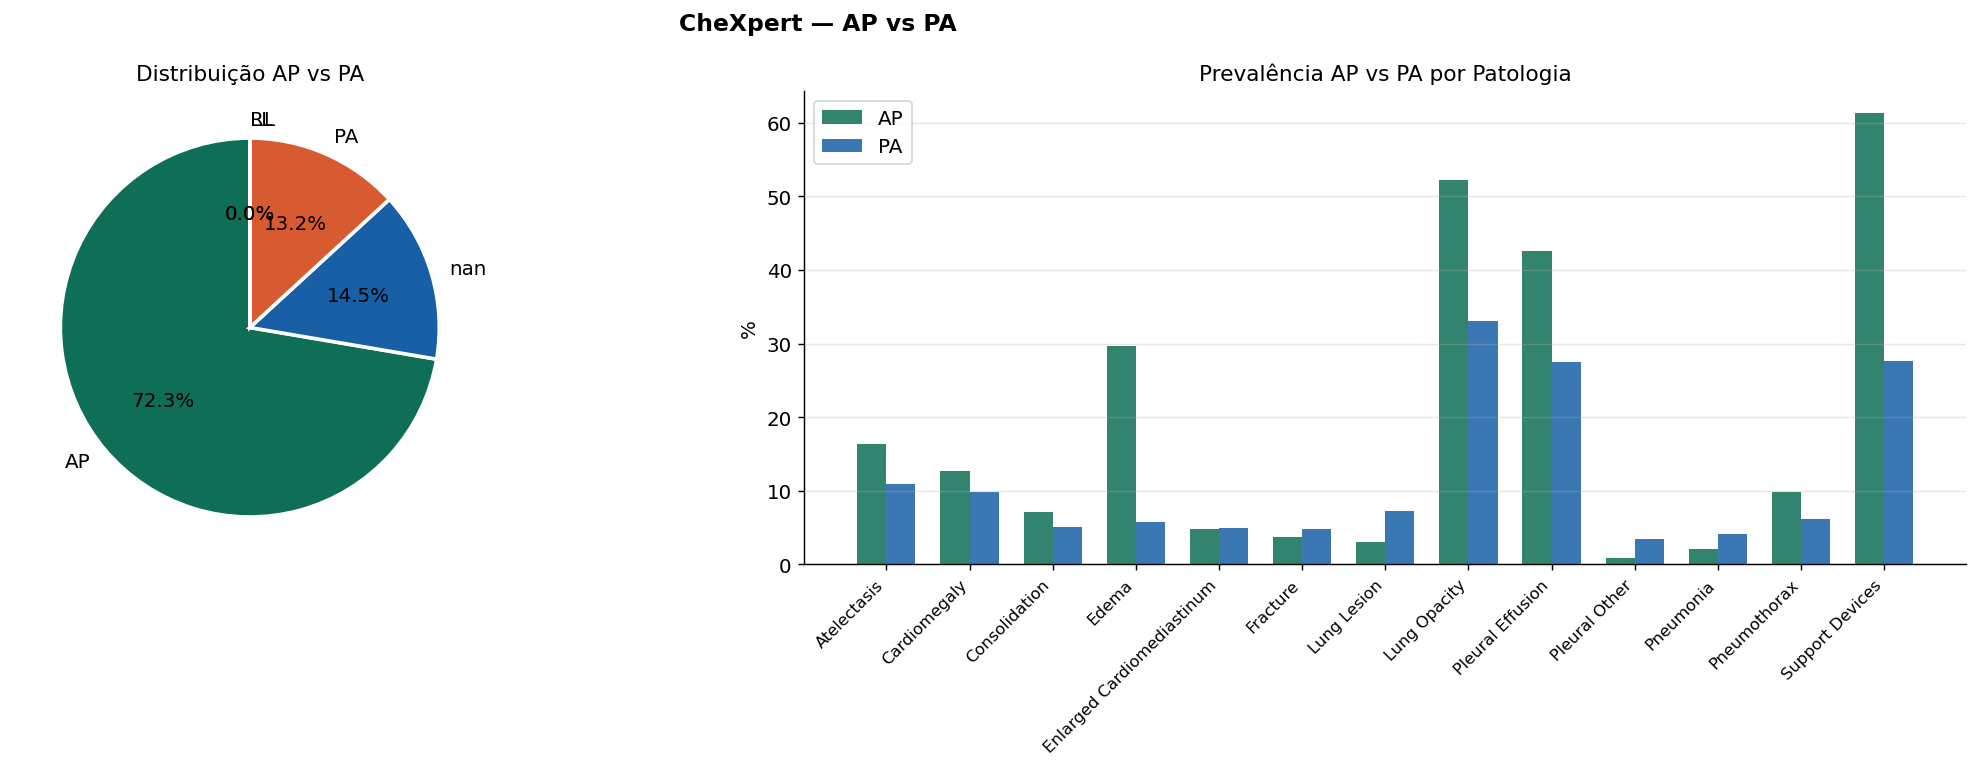

  Salvo: MyDrive/Results/analise_CheXpert/plots/sec12_ap_vs_pa.png


In [ ]:
section('SEÇÃO 12 — AP vs PA por Patologia (CheXpert)')

if 'AP/PA' not in df_chex_train.columns:
    log('Coluna AP/PA não encontrada.')
else:
    ap_pa_dist = df_chex_train['AP/PA'].value_counts(dropna=False)
    log('Distribuição geral AP/PA:')
    for v, cnt in ap_pa_dist.items():
        log(f'  {str(v):<8}: {cnt:,} ({cnt/len(df_chex_train)*100:.1f}%)')

    ap_data = []
    log(f'\n{"Label":<35} {"AP %":>10} {"PA %":>10} {"Diferença":>12}')
    log('-' * 70)
    for lbl in CHEX_LABELS_NO_NF:
        if lbl not in df_chex_train.columns: continue
        for ap_val in df_chex_train['AP/PA'].dropna().unique():
            sub  = df_chex_train[df_chex_train['AP/PA']==ap_val]
            prev = (sub[lbl]==1).mean()*100 if len(sub)>0 else 0
            ap_data.append({'label': lbl, 'ap_pa': ap_val, 'prevalencia_pct': round(prev,2)})

    df_ap = pd.DataFrame(ap_data)
    if not df_ap.empty and 'AP' in df_ap['ap_pa'].values and 'PA' in df_ap['ap_pa'].values:
        ap_only = df_ap[df_ap['ap_pa']=='AP'].set_index('label')['prevalencia_pct']
        pa_only = df_ap[df_ap['ap_pa']=='PA'].set_index('label')['prevalencia_pct']
        for lbl in CHEX_LABELS_NO_NF:
            if lbl in ap_only.index and lbl in pa_only.index:
                diff = ap_only[lbl] - pa_only[lbl]
                log(f'{lbl:<35} {ap_only[lbl]:>9.2f}% {pa_only[lbl]:>9.2f}% {diff:>+11.2f}%')

        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        fig.suptitle('CheXpert — AP vs PA', fontsize=13, fontweight='bold')
        axes[0].pie(ap_pa_dist.values, labels=ap_pa_dist.index, autopct='%1.1f%%',
                    colors=[C_CHEX, C_NIH, C_WARN, C_GRAY][:len(ap_pa_dist)],
                    startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
        axes[0].set_title('Distribuição AP vs PA')

        common_lbls = [l for l in CHEX_LABELS_NO_NF if l in ap_only.index and l in pa_only.index]
        x = np.arange(len(common_lbls)); w = 0.35
        axes[1].bar(x-w/2, [ap_only[l] for l in common_lbls], w, label='AP', color=C_CHEX, alpha=0.85)
        axes[1].bar(x+w/2, [pa_only[l] for l in common_lbls], w, label='PA', color=C_NIH,  alpha=0.85)
        axes[1].set_xticks(x); axes[1].set_xticklabels(common_lbls, rotation=45, ha='right', fontsize=9)
        axes[1].set_title('Prevalência AP vs PA por Patologia')
        axes[1].set_ylabel('%'); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
        save_fig(fig, f'{PLOTS_CHEX}/sec12_ap_vs_pa.png')

    df_ap.to_csv(f'{TABLES_DIR}/12_ap_pa_prevalence.csv', index=False)

---
# SEÇÃO 13 — Arquivos Faltantes vs CSV

In [ ]:
section('SEÇÃO 13 — Arquivos Faltantes vs CSV (CheXpert)')

log('CheXpert — verificando todos os arquivos por batch...')

results_batch = {}
for batch in ['batch2_train1', 'batch3_train2', 'batch4_train3']:
    subset = df_chex_train[
        df_chex_train['Path'].apply(
            lambda p: batch_index.get(str(p).split('/')[2] if len(str(p).split('/'))>=3 else '') == batch
        )
    ].copy()
    if len(subset) == 0: continue
    t_b = time.time()

    has_path  = subset['abs_path'].notna()
    nan_paths = int((~has_path).sum())
    exists    = subset.loc[has_path, 'abs_path'].apply(os.path.exists)
    found     = int(exists.sum())
    missing   = int((~exists).sum())

    results_batch[batch] = {
        'total': len(subset), 'found': found,
        'missing': missing, 'nan_path': nan_paths
    }
    log(f'  {batch:<30}: {found:,}/{len(subset):,} encontrados | '
        f'{missing:,} faltando | {nan_paths:,} sem path ({time.time()-t_b:.0f}s)')

# Valid
val_has_path  = df_chex_valid['abs_path'].notna()
val_nan_paths = int((~val_has_path).sum())
val_exists    = df_chex_valid.loc[val_has_path, 'abs_path'].apply(os.path.exists)
val_found     = int(val_exists.sum())
val_missing   = int((~val_exists).sum())

results_batch['valid'] = {
    'total': len(df_chex_valid), 'found': val_found,
    'missing': val_missing, 'nan_path': val_nan_paths
}
log(f'  {"valid":<30}: {val_found:,}/{len(df_chex_valid):,} encontrados | '
    f'{val_missing:,} faltando | {val_nan_paths:,} sem path')

# Totais
total_chex   = sum(v['total']    for v in results_batch.values())
found_chex   = sum(v['found']    for v in results_batch.values())
missing_chex = sum(v['missing']  for v in results_batch.values())
nan_chex     = sum(v['nan_path'] for v in results_batch.values())

log(f'\nCheXpert — TOTAL:')
log(f'  Encontrados : {found_chex:,}')
log(f'  Faltando    : {missing_chex:,}')
log(f'  Sem path    : {nan_chex:,}')
log(f'  Total CSV   : {total_chex:,}')
log(f'  Verificação : {found_chex + missing_chex + nan_chex:,} == {total_chex:,} '
    f'{"✅" if found_chex + missing_chex + nan_chex == total_chex else "❌"}')
log(f'  Cobertura   : {found_chex/total_chex*100:.3f}%')

import json as _json
with open(f'{TABLES_DIR}/sec13_chex_missing.json', 'w') as f:
    _json.dump({
        'CheXpert': {
            'total': total_chex, 'found': found_chex,
            'missing': missing_chex, 'nan_path': nan_chex
        },
        'batches': results_batch
    }, f, indent=2)
log('\nRelatório salvo.')


SEÇÃO 13 — Arquivos Faltantes vs CSV (CheXpert)
CheXpert — verificando todos os arquivos por batch...
  batch2_train1                 : 89,483/89,484 encontrados | 1 faltando | 0 sem path (18509s)
  batch3_train2                 : 92,952/92,953 encontrados | 1 faltando | 0 sem path (23774s)
  batch4_train3                 : 40,977/40,977 encontrados | 0 faltando | 0 sem path (12581s)
  valid                         : 234/234 encontrados | 0 faltando | 0 sem path

CheXpert — TOTAL:
  Encontrados : 223,646
  Faltando    : 2
  Sem path    : 0
  Total CSV   : 223,648
  Verificação : 223,648 == 223,648 ✅
  Cobertura   : 99.999%

Relatório salvo.


---
# SEÇÃO 14 — Distribuição de Estudos por Paciente


SEÇÃO 14 — Distribuição de Estudos por Paciente (CheXpert)
CheXpert — Estudos por paciente:
  Pacientes únicos    : 64,740
  Média estudos/pac.  : 3.45
  Mediana             : 2.0
  Máx estudos/pac.    : 92
  1 estudo (único)    : 22,750 (35.1%)
  5+ estudos          : 12,762 (19.7%)


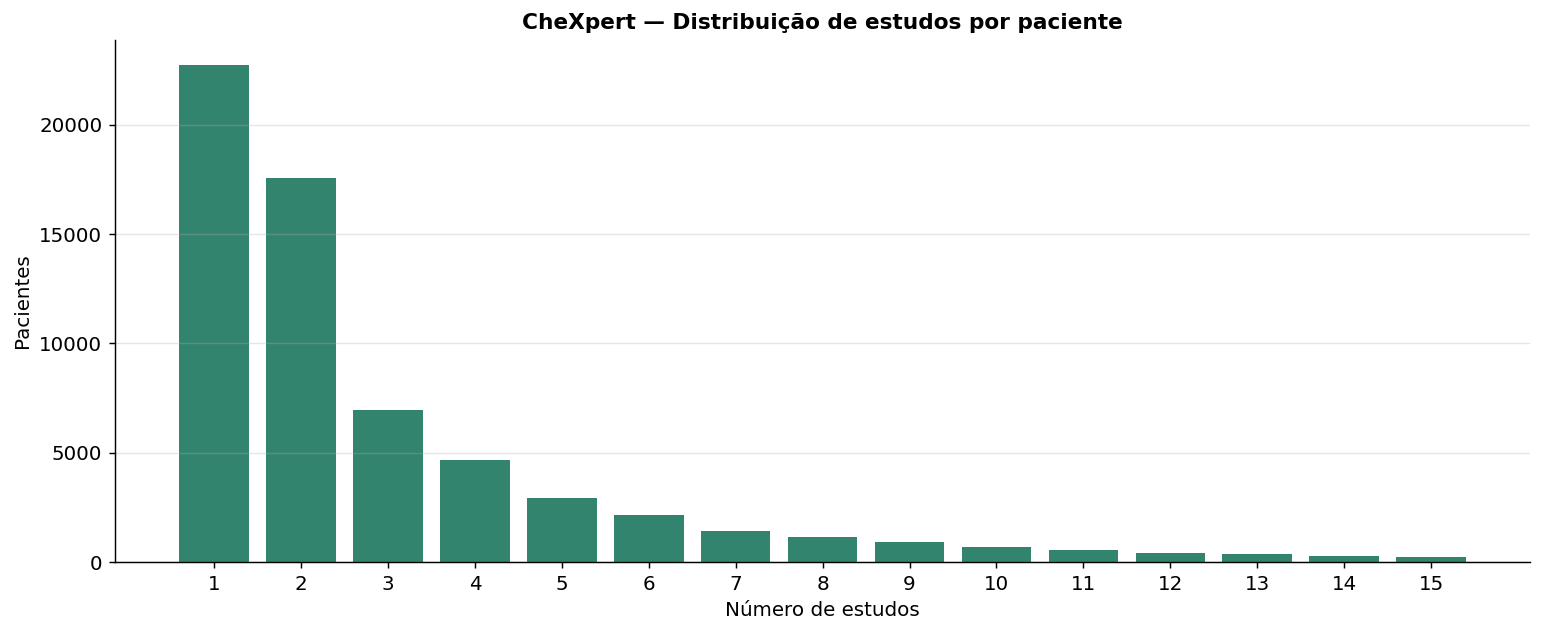

  Salvo: MyDrive/Results/analise_CheXpert/plots/sec14_studies_per_patient.png


In [ ]:
section('SEÇÃO 14 — Distribuição de Estudos por Paciente (CheXpert)')

df_chex['patient_id'] = df_chex['Path'].apply(lambda p: str(p).split('/')[2])
chex_studies = df_chex.groupby('patient_id').size()

log('CheXpert — Estudos por paciente:')
log(f'  Pacientes únicos    : {len(chex_studies):,}')
log(f'  Média estudos/pac.  : {chex_studies.mean():.2f}')
log(f'  Mediana             : {chex_studies.median():.1f}')
log(f'  Máx estudos/pac.    : {chex_studies.max()}')
log(f'  1 estudo (único)    : {(chex_studies==1).sum():,} ({(chex_studies==1).mean()*100:.1f}%)')
log(f'  5+ estudos          : {(chex_studies>=5).sum():,} ({(chex_studies>=5).mean()*100:.1f}%)')

chex_study_dist = chex_studies.value_counts().sort_index().head(15)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(chex_study_dist.index.astype(str), chex_study_dist.values, color=C_CHEX, alpha=0.85)
ax.set_title('CheXpert — Distribuição de estudos por paciente', fontweight='bold')
ax.set_xlabel('Número de estudos'); ax.set_ylabel('Pacientes')
ax.grid(axis='y', alpha=0.3)
save_fig(fig, f'{PLOTS_CHEX}/sec14_studies_per_patient.png')
chex_studies.value_counts().sort_index().to_csv(f'{TABLES_DIR}/14_chex_studies_per_patient.csv')

---
# SEÇÃO 16 — Relatório Completo e Resumo Estratégico

In [ ]:
section('SEÇÃO 16 — Relatório Completo CheXpert')

chex_bin = df_chex_train[CHEX_LABELS_NO_NF].fillna(0).clip(lower=0)
chex_n_labels = chex_bin.sum(axis=1)

# Aspect ratio summary (da SEÇÃO 1)
ar_info = ''
if chex_sizes_frontal:
    ws = [s[0] for s in chex_sizes_frontal]; hs = [s[1] for s in chex_sizes_frontal]
    ar_medio = np.mean([h/w for w,h in zip(ws,hs)])
    portrait_pct = sum(1 for h,w in zip(hs,ws) if h > w) / len(ws) * 100
    ar_info = f'    Aspect ratio médio frontal: {ar_medio:.3f} | {portrait_pct:.1f}% portrait'

summary_lines = [
    '',
    '=' * 65,
    'RESUMO ESTRATÉGICO — Stanford CheXpert Full',
    '=' * 65,
    '',
    '[1] DATASET',
    f'    Train: {len(df_chex_train):,} imagens | Valid: {len(df_chex_valid):,} imagens',
    f'    Resolução: JPEG variável (~2000–3000 px)',
    '',
    '[2] TAMANHO DE IMAGEM (Seção 1)',
    ar_info,
    '    → Decisão: Zero-padding ou Center Crop para normalizar para 512×512?',
    '    → Ver scatter plots em plots/sec01_image_sizes.png',
    '',
    '[3] FRONTAL vs LATERAL',
    '    → Decisão: filtrar apenas frontais (como CheXNet) ou treinar com ambas?',
    '    → Laterais têm distribuição de patologias distinta (ver Seção 3).',
    '',
    '[4] LABELS INCERTOS (-1)',
    f'    Total de labels -1 no train: {sum(v["unc"] for v in chex_tern.values()):,}',
    '    → Definir política U-Ones vs U-Ignore antes do treino (ver Seção 6).',
    '',
    '[5] DESBALANCEAMENTO',
    '    → Usar Weighted Loss ou Focal Loss — ver Seção 4 para ratios por label.',
    '',
    '[6] COMPLEXIDADE MULTI-LABEL',
    f'    Média de labels/imagem: {chex_n_labels.mean():.2f}',
    '    → Alta co-ocorrência entre labels (ver Seção 8).',
    '',
    '=' * 65,
]

for l in summary_lines:
    log(l)

with open(REPORT_PATH, 'w', encoding='utf-8') as f:
    f.write('\n'.join(REPORT_LINES))

print(f'\nRelatório salvo: {REPORT_PATH}')
print(f'  {len(REPORT_LINES)} linhas')
print(f'\nArquivos gerados em {ANALYSIS_DIR.replace(BASE_DRIVE, "MyDrive")}:')
for root, dirs, files in os.walk(ANALYSIS_DIR):
    for fn in sorted(files):
        fpath = os.path.join(root, fn)
        size  = os.path.getsize(fpath)
        unit  = 'KB' if size < 1024**2 else 'MB'
        sv    = size/1024 if size < 1024**2 else size/1024**2
        rel   = fpath.replace(ANALYSIS_DIR+'/', '')
        print(f'  {rel:<55} {sv:>6.1f} {unit}')


SEÇÃO 16 — Relatório Completo CheXpert

RESUMO ESTRATÉGICO — Stanford CheXpert Full

[1] DATASET
    Train: 223,414 imagens | Valid: 234 imagens
    Resolução: JPEG variável (~2000–3000 px)

[2] TAMANHO DE IMAGEM (Seção 1)
    Aspect ratio médio frontal: 0.842 | 2.3% portrait
    → Decisão: Zero-padding ou Center Crop para normalizar para 512×512?
    → Ver scatter plots em plots/sec01_image_sizes.png

[3] FRONTAL vs LATERAL
    → Decisão: filtrar apenas frontais (como CheXNet) ou treinar com ambas?
    → Laterais têm distribuição de patologias distinta (ver Seção 3).

[4] LABELS INCERTOS (-1)
    Total de labels -1 no train: 139,958
    → Definir política U-Ones vs U-Ignore antes do treino (ver Seção 6).

[5] DESBALANCEAMENTO
    → Usar Weighted Loss ou Focal Loss — ver Seção 4 para ratios por label.

[6] COMPLEXIDADE MULTI-LABEL
    Média de labels/imagem: 2.21
    → Alta co-ocorrência entre labels (ver Seção 8).


Relatório salvo: /content/drive/MyDrive/Results/analise_CheXpert/rel